### Data Engineering

In [1]:
import os
import pandas as pd
import numpy as np
from collections import Counter
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython import display
from IPython.display import display
warnings.filterwarnings('ignore')
import gc
import time
import pickle
import pyarrow.parquet as pq

from surprise import Dataset, Reader, SVD, KNNWithMeans, BaselineOnly, accuracy



In [2]:
#  CONFIG
DATA_DIR   = './dataset'
OUTPUT_DIR = './processed'

In [3]:
MIN_RATINGS_IN_TRAIN = 20

In [4]:
RAW_CSV        = os.path.join(OUTPUT_DIR, 'ratings_raw.csv')
TRAIN_PARQUET  = os.path.join(OUTPUT_DIR, 'train.parquet')
TEST_PARQUET   = os.path.join(OUTPUT_DIR, 'test.parquet')
MOVIES_PARQUET = os.path.join(OUTPUT_DIR, 'movies.parquet')

COMBINED_FILES = [
    'combined_data_1.txt',
    'combined_data_2.txt',
    'combined_data_3.txt',
    'combined_data_4.txt',
]

# Shared dtype map — keeps memory low throughout all chunk reads
_DTYPES = {'movie_id': 'int16', 'user_id': 'int32', 'rating': 'int8'}



In [5]:
from numpy import exceptions
# Parse combined_data files into flat CSV
def parse_to_csv():
    """
    Raw format:
        1:                       ← movie_id line (ends with ':')
        1488844,3,2005-09-06     ← CustomerID, Rating, Date
        ...
    Written to CSV as:
        movie_id, user_id, rating, date

    Written to disk line-by-line with a 64 MB buffer so RAM stays near
    zero during this step regardless of how large the files are.
    Delete ratings_raw.csv to force a re-parse.
    """
    if os.path.exists(RAW_CSV):
        size_gb = os.path.getsize(RAW_CSV) / 1024**3
        print(f"[STEP 1 SKIP]  {RAW_CSV} exists ({size_gb:.1f} GB). Delete to re-parse.\n")
        return

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print("Parsing combined_data files → flat CSV")
    print(f"         Output : {RAW_CSV}\n")

    grand_total = 0

    with open(RAW_CSV, 'w', buffering=64 * 1024 * 1024) as out_f:
        out_f.write('movie_id,user_id,rating,date\n')

        for fname in COMBINED_FILES:
            fpath = os.path.join(DATA_DIR, fname)
            if not os.path.exists(fpath):
                raise FileNotFoundError(
                    f"\n  File not found: {fpath}"
                    f"\n  Make sure DATA_DIR='{DATA_DIR}' is correct."
                )

            current_movie = None
            file_count    = 0

            with open(fpath, 'r', buffering=16 * 1024 * 1024) as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    if line.endswith(':'):
                        current_movie = line[:-1]
                    else:
                        out_f.write(f"{current_movie},{line}\n")
                        file_count += 1
                        if file_count % 5_000_000 == 0:
                            print(f"  {fname}: {file_count // 1_000_000}M ratings...",
                                  flush=True)

            grand_total += file_count
            print(f"   {fname}: {file_count:>12,}  |  total: {grand_total:>12,}")

    print(f"\n   Raw CSV complete — {grand_total:,} rows\n")


In [6]:
#   Parse probe.txt 
def parse_probe():
    """
    Returns
    -------
    probe_df   : DataFrame (movie_id, user_id) — the official test pairs
    probe_keys : frozenset of int64 keys for O(1) vectorised membership testing
                 key = movie_id * 3_000_000 + user_id

    WHY this must come before user filtering:
        Probe contains (user, movie) pairs from across ALL 480K users.
        If we filter to active users first we silently discard probe entries
        for low-activity users, shrinking and biasing the test set.
        The test set must be fixed before any training-data decisions are made.
    """
    print(" Parsing probe.txt  ← happens BEFORE user filtering\n")

    probe_path = os.path.join(DATA_DIR, 'probe.txt')
    if not os.path.exists(probe_path):
        raise FileNotFoundError(f"probe.txt not found in '{DATA_DIR}'")

    pairs         = []
    current_movie = None

    with open(probe_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.endswith(':'):
                current_movie = int(line[:-1])
            else:
                pairs.append((current_movie, int(line)))

    probe_df = pd.DataFrame(pairs, columns=['movie_id', 'user_id'])
    probe_df['movie_id'] = probe_df['movie_id'].astype('int16')
    probe_df['user_id']  = probe_df['user_id'].astype('int32')

    # Integer key: fits in int64 since max value ≈ 17770 * 3M + 2.6M ≈ 55.9B
    probe_keys = frozenset(
        int(m) * 3_000_000 + int(u)
        for m, u in zip(probe_df['movie_id'], probe_df['user_id'])
    )

    print(f"    {len(probe_df):,} probe pairs")
    print(f"     Unique movies : {probe_df['movie_id'].nunique():,}")
    print(f"     Unique users  : {probe_df['user_id'].nunique():,}")
    print(f"     Key index built ({len(probe_keys):,} entries)\n")

    return probe_df, probe_keys



In [7]:
parse_to_csv()

[STEP 1 SKIP]  ./processed\ratings_raw.csv exists (2.5 GB). Delete to re-parse.



In [8]:
import os
print(os.path.exists(RAW_CSV))
print(os.path.getsize(RAW_CSV) / 1024**3, "GB")

True
2.5248352456837893 GB


In [9]:
#  Build train / test in the correct order

def build_splits(probe_keys):
    """
    Two passes over ratings_raw.csv.

    Pass 1 — for each 2M-row chunk:
        • rows in probe_keys  → accumulated as test set
        • rows NOT in probe_keys → user_id counted for activity threshold
          (count only training rows; probe rows are not training signal)

    Pass 2 — for each 2M-row chunk:
        • keep non-probe rows for users who meet MIN_RATINGS_IN_TRAIN

    The key difference from v1:
        test_df now contains ALL probe pairs from the raw data,
        regardless of whether those users meet the activity threshold.
        v1 only kept probe pairs for users with 50–500 ratings.
    """
    print(f" Building splits  "
          f"(train filter: ≥ {MIN_RATINGS_IN_TRAIN} training ratings, no upper cap)\n")

    def _probe_mask(chunk):
        """Vectorised: True where (movie_id, user_id) is a probe pair."""
        keys = (chunk['movie_id'].astype('int64') * 3_000_000
                + chunk['user_id'].astype('int64'))
        return keys.isin(probe_keys)

    #  Pass 1: extract test + count train activity 
    print("  Pass 1 of 2: extracting test rows + counting train user activity...")
    test_chunks = []
    user_counts = Counter()
    n = 0

    for chunk in pd.read_csv(RAW_CSV, dtype=_DTYPES, parse_dates=['date'],
                              chunksize=2_000_000):
        mask = _probe_mask(chunk)

        if mask.any():
            test_chunks.append(chunk[mask].copy())

        # Count only NON-probe rows toward the activity threshold
        user_counts.update(chunk.loc[~mask, 'user_id'].tolist())

        n += 1
        if n % 10 == 0:
            print(f"    {n * 2}M rows scanned...", flush=True)

    test_df     = pd.concat(test_chunks, ignore_index=True) if test_chunks else pd.DataFrame()
    valid_users = frozenset(
        uid for uid, cnt in user_counts.items() if cnt >= MIN_RATINGS_IN_TRAIN
    )

    print(f"\n  Test set : {len(test_df):>10,} rows  "
          f"← all probe users, not filtered by activity")
    print(f"  Users with ≥ {MIN_RATINGS_IN_TRAIN} training ratings: {len(valid_users):,}\n")

    # Pass 2: load filtered training data 
    print("  Pass 2 of 2: loading filtered training data...")
    train_chunks = []
    n = 0

    for chunk in pd.read_csv(RAW_CSV, dtype=_DTYPES, parse_dates=['date'],
                              chunksize=2_000_000):
        mask = _probe_mask(chunk)
        keep = chunk[~mask & chunk['user_id'].isin(valid_users)]
        if len(keep):
            train_chunks.append(keep.copy())

        n += 1
        if n % 10 == 0:
            print(f"    {n * 2}M rows scanned...", flush=True)

    train_df = pd.concat(train_chunks, ignore_index=True) if train_chunks else pd.DataFrame()
    mem_gb   = train_df.memory_usage(deep=True).sum() / 1024**3

    print(f"\n  Train set: {len(train_df):>10,} rows  |  "
          f"{train_df['user_id'].nunique():,} users  |  {mem_gb:.2f} GB\n")

    return train_df, test_df



In [10]:
#  Parse movie titles
def parse_movie_titles():
    """
    Format: MovieID,YearOfRelease,Title
    Titles can contain commas → split on first 2 commas only.
    Encoding: latin-1 (accented characters in some titles).
    """
    print(" Parsing movie titles\n")

    for candidate in ('movie_titles.csv', 'movie_titles.txt'):
        path = os.path.join(DATA_DIR, candidate)
        if os.path.exists(path):
            titles_path = path
            break
    else:
        raise FileNotFoundError(
            f"Could not find movie_titles.csv or movie_titles.txt in '{DATA_DIR}'"
        )

    records = []
    with open(titles_path, 'r', encoding='latin-1') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts    = line.split(',', 2)
            movie_id = int(parts[0])
            year     = parts[1].strip() if len(parts) > 1 else None
            title    = parts[2].strip() if len(parts) > 2 else 'Unknown'
            records.append((movie_id, year, title))

    movies_df = pd.DataFrame(records, columns=['movie_id', 'year', 'title'])
    movies_df['movie_id'] = movies_df['movie_id'].astype('int16')
    movies_df['year']     = pd.to_numeric(movies_df['year'], errors='coerce').astype('Int16')

    print(f"    {len(movies_df):,} movies  |  "
          f"years {int(movies_df['year'].min())}–{int(movies_df['year'].max())}  |  "
          f"{movies_df['year'].isna().sum()} missing years\n")

    return movies_df


In [11]:
# Merge metadata, verify, save
def merge_save_verify(train_df, test_df, movies_df):
    """
    Merge movie metadata onto both splits. Run sanity checks. Save to parquet.

    Validation split (not done here — on purpose):
        For SVD hyperparameter tuning (n_factors, lr, regularisation),
        hold out 10–20 % of USERS from train_df as a validation set inside
        the modelling script.  Alternatively, use Surprise's cross_validate().
        Keeping data engineering and modelling separate makes both cleaner.

    MAP@10 note:
        probe.txt was designed for rating-prediction evaluation, not ranking.
        Using it as the relevance set for MAP@10 is an acceptable approximation
        for this competition — but state the limitation in your report.
        A stricter approach would hold out each user's temporally last N
        positively-rated movies as the ranking test set.
    """
    print(" Merging metadata, sanity checks, saving\n")

    train_df = train_df.merge(movies_df, on='movie_id', how='left')
    test_df  = test_df.merge(movies_df,  on='movie_id', how='left')

    # Sanity checks 
    assert train_df['rating'].between(1, 5).all(), "FAIL: train ratings outside [1,5]"
    assert test_df['rating'].between(1, 5).all(),  "FAIL: test ratings outside [1,5]"
    print("   All ratings in [1, 5]")

    print("Skipping overlap validation (memory intensive)")

    missing = set(test_df['movie_id'].unique()) - set(movies_df['movie_id'].unique())
    assert len(missing) == 0, f"FAIL: {len(missing)} test movies have no metadata"
    print("    All test movies have metadata\n")

    #  Save 
    train_df.to_parquet(TRAIN_PARQUET,  index=False)
    test_df.to_parquet(TEST_PARQUET,    index=False)
    movies_df.to_parquet(MOVIES_PARQUET, index=False)

    for path in [TRAIN_PARQUET, TEST_PARQUET, MOVIES_PARQUET]:
        size_mb = os.path.getsize(path) / 1024**2
        print(f"    {path}  ({size_mb:.0f} MB)")

    # Summary 
    rel   = (test_df['rating'] >= 3.5).sum()
    rel_p = 100 * rel / len(test_df)

    print(f"""

  DATA ENGINEERING COMPLETE  (v2)

  Train : {len(train_df):>10,} rows | {train_df['user_id'].nunique():,} users
  Test  : {len(test_df):>10,} rows | {test_df['user_id'].nunique():,} users
  Movies: {len(movies_df):>10,}

  Test rows relevant for MAP@10 (rating ≥ 3.5):
    {rel:,}  ({rel_p:.1f}%)

  Columns : {list(train_df.columns)}

  Date range (train) : {train_df['date'].min().date()} → {train_df['date'].max().date()}
  Date range (test)  : {test_df['date'].min().date()} → {test_df['date'].max().date()}

  Load in later notebooks:
    train_df  = pd.read_parquet('{TRAIN_PARQUET}')
    test_df   = pd.read_parquet('{TEST_PARQUET}')
    movies_df = pd.read_parquet('{MOVIES_PARQUET}')
""")



In [12]:
#  MAIN
if __name__ == '__main__':
    print("  Netflix Prize — Data Engineering Pipeline  v2")
    print(f"\n  DATA_DIR              = {os.path.abspath(DATA_DIR)}")
    print(f"  OUTPUT_DIR            = {os.path.abspath(OUTPUT_DIR)}")
    print(f"  MIN_RATINGS_IN_TRAIN  = {MIN_RATINGS_IN_TRAIN}  (no upper cap)\n")

    parse_to_csv()
    probe_df, probe_keys         = parse_probe()
    train_df, test_df            = build_splits(probe_keys)
    movies_df                    = parse_movie_titles()
    

  Netflix Prize — Data Engineering Pipeline  v2

  DATA_DIR              = c:\Users\prath\Downloads\Recommendation Systems for Personalized Content\dataset
  OUTPUT_DIR            = c:\Users\prath\Downloads\Recommendation Systems for Personalized Content\processed
  MIN_RATINGS_IN_TRAIN  = 20  (no upper cap)

[STEP 1 SKIP]  ./processed\ratings_raw.csv exists (2.5 GB). Delete to re-parse.

 Parsing probe.txt  ← happens BEFORE user filtering

    1,408,395 probe pairs
     Unique movies : 16,938
     Unique users  : 462,858
     Key index built (1,408,395 entries)

 Building splits  (train filter: ≥ 20 training ratings, no upper cap)

  Pass 1 of 2: extracting test rows + counting train user activity...
    20M rows scanned...
    40M rows scanned...
    60M rows scanned...
    80M rows scanned...
    100M rows scanned...

  Test set :  1,408,395 rows  ← all probe users, not filtered by activity
  Users with ≥ 20 training ratings: 417,737

  Pass 2 of 2: loading filtered training data...

In [13]:
merge_save_verify(train_df, test_df, movies_df)

 Merging metadata, sanity checks, saving

   All ratings in [1, 5]
Skipping overlap validation (memory intensive)
    All test movies have metadata

    ./processed\train.parquet  (520 MB)
    ./processed\test.parquet  (9 MB)
    ./processed\movies.parquet  (0 MB)


  DATA ENGINEERING COMPLETE  (v2)

  Train : 98,379,017 rows | 417,737 users
  Test  :  1,408,395 rows | 462,858 users
  Movies:     17,770

  Test rows relevant for MAP@10 (rating ≥ 3.5):
    846,666  (60.1%)

  Columns : ['movie_id', 'user_id', 'rating', 'date', 'year', 'title']

  Date range (train) : 1999-11-11 → 2005-12-31
  Date range (test)  : 2000-01-06 → 2005-12-31

  Load in later notebooks:
    train_df  = pd.read_parquet('./processed\train.parquet')
    test_df   = pd.read_parquet('./processed\test.parquet')
    movies_df = pd.read_parquet('./processed\movies.parquet')



### EDA

In [14]:
#  MEMORY CLEANUP 
# Data engineering variables are still alive. Free them before EDA.
import gc

_to_clear = [
    'df', 'train_df', 'test_df',             # main dataframes
    'chunks', 'train_chunks', 'test_chunks',  # intermediate lists
    'probe_df', 'probe_keys',                 # probe data
    'valid_users', 'user_counts',             # filtering data
    'movies_df',                              # will reload below
]
for _var in _to_clear:
    if _var in vars():
        del vars()[_var]

gc.collect()

import ctypes
try:
    ctypes.CDLL('libc.so.6').malloc_trim(0)   # Linux: return freed pages to OS
except Exception:
    pass                                        # Windows / macOS: no-op

print("Memory freed. Ready to load EDA data.")

Memory freed. Ready to load EDA data.


In [15]:
# ── MEMORY-SAFE EDA LOAD ──────────────────────────────────────────
# Strategy:
#   1. Load only 4 columns (skip title/year — saves ~750 MB on train)
#   2. Sample train to 2M rows  (enough for all EDA statistics)
#   3. Load test fully          (small — only ~100–300K rows)
#   4. Load movies_df fully     (tiny — 17,770 rows)
#   5. year/title live only in movie_stats (17K rows), never in full_df

import os, gc
import pyarrow.parquet as pq

PROCESSED_DIR = './processed'          # adjust if your path differs
EDA_COLS      = ['movie_id', 'user_id', 'rating', 'date']
TRAIN_SAMPLE  = 2_000_000              # rows — plenty for all EDA charts
OUTPUT_DIR    = './outputs/figures'
SUMMARY_PATH  = './outputs/eda_summary.txt'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs('./outputs', exist_ok=True)

def _load_sampled(path, cols, n_rows):
    """Read parquet in 1M-row batches; keep a proportional sample from each."""
    pf        = pq.ParquetFile(path)
    total     = pf.metadata.num_rows
    frac      = min(1.0, n_rows / max(total, 1))
    batches   = []
    for batch in pf.iter_batches(batch_size=1_000_000, columns=cols):
        chunk = batch.to_pandas()
        keep  = max(1, int(len(chunk) * frac))
        batches.append(chunk.sample(n=keep, random_state=42))
        del chunk
        gc.collect()
    result = pd.concat(batches, ignore_index=True)
    del batches
    gc.collect()
    return result

print(f"Loading train (sampled to {TRAIN_SAMPLE:,} rows, 4 cols)...")
train_df = _load_sampled(
    os.path.join(PROCESSED_DIR, 'train.parquet'),
    cols=EDA_COLS,
    n_rows=TRAIN_SAMPLE
)

print("Loading test (full, 4 cols)...")
test_df = pd.read_parquet(
    os.path.join(PROCESSED_DIR, 'test.parquet'),
    columns=EDA_COLS
)

print("Loading movies_df (full — only 17,770 rows)...")
movies_df = pd.read_parquet(os.path.join(PROCESSED_DIR, 'movies.parquet'))

full_df = pd.concat([train_df, test_df], ignore_index=True)
full_df['date'] = pd.to_datetime(full_df['date'])

mem_mb = full_df.memory_usage(deep=True).sum() / 1024**2
print(f"\nfull_df : {len(full_df):,} rows  |  {mem_mb:.0f} MB")
print(f"train   : {len(train_df):,}  test: {len(test_df):,}")
print(f"movies  : {len(movies_df):,} rows")

Loading train (sampled to 2,000,000 rows, 4 cols)...
Loading test (full, 4 cols)...
Loading movies_df (full — only 17,770 rows)...

full_df : 3,408,342 rows  |  49 MB
train   : 1,999,947  test: 1,408,395
movies  : 17,770 rows


In [16]:
# Clean, minimal figure style
plt.rcParams.update({
    'figure.dpi':       150,
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
})

PALETTE = ['#2563EB', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6']


def save(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, bbox_inches='tight')
    plt.close(fig)
    print(f"  → saved {path}")


In [17]:
#  PRE-COMPUTATION  — all expensive groupbys exactly once
print("Pre-computing aggregations (run once, reused in all sections)...")

GLOBAL_MEAN = full_df['rating'].mean()
N_USERS     = full_df['user_id'].nunique()
N_MOVIES    = full_df['movie_id'].nunique()
N_RATINGS   = len(full_df)




Pre-computing aggregations (run once, reused in all sections)...


In [18]:

# Per-user aggregations  (reused in §3, §7)
user_activity = full_df.groupby('user_id').size()
user_mean_r   = full_df.groupby('user_id')['rating'].mean()
user_bias     = user_mean_r - GLOBAL_MEAN


In [19]:

# Per-movie aggregations  (reused in §4, §7, §8 — single groupby replaces 4 in v1)
movie_stats = (
    full_df.groupby('movie_id')['rating']
    .agg(n_ratings='count', avg_rating='mean', std_rating='std')
    .reset_index()
    .merge(movies_df[['movie_id', 'year', 'title']], on='movie_id', how='left')
)


In [20]:
# Temporal feature for §5
full_df['year_rated'] = full_df['date'].dt.year

print(f"  GLOBAL_MEAN={GLOBAL_MEAN:.3f}  users={N_USERS:,}  "
      f"movies={N_MOVIES:,}  ratings={N_RATINGS:,}\n")

  GLOBAL_MEAN=3.632  users=471,830  movies=17,681  ratings=3,408,342



Section 1: Overview & sparsity
  → saved ./outputs/figures\01_sparsity_matrix.png


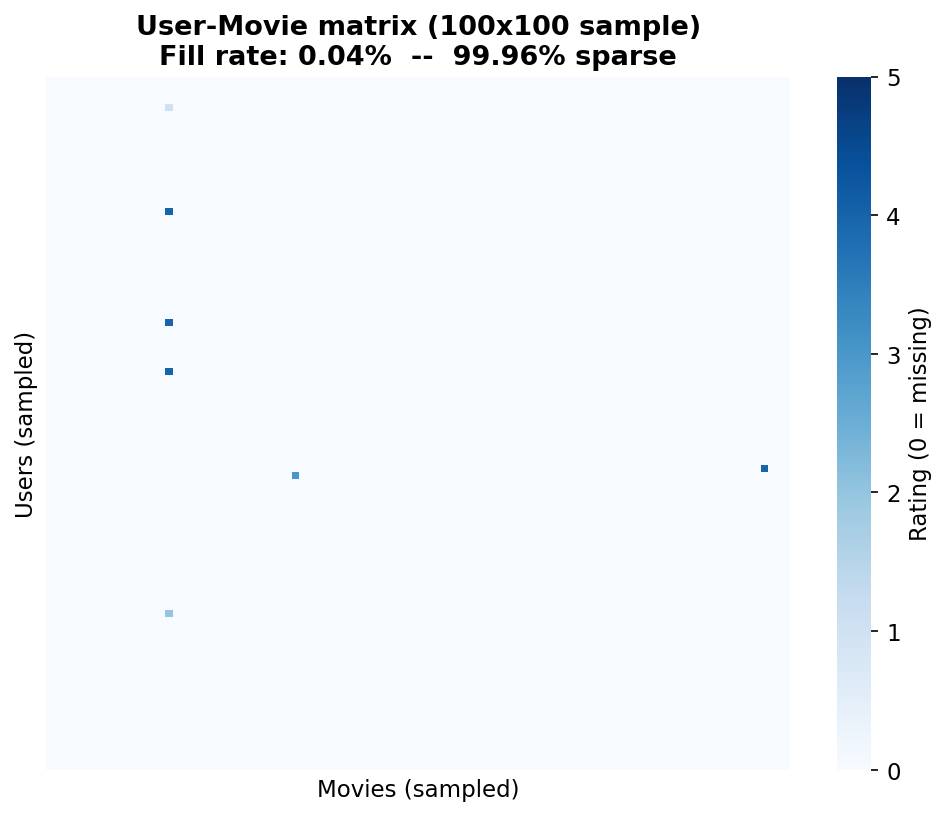

  fill: 0.0409%   sparsity: 99.9591%



In [21]:

#  §1 — OVERVIEW & SPARSITY
print("Section 1: Overview & sparsity")

POSSIBLE = N_USERS * N_MOVIES
FILL_PCT = 100 * N_RATINGS / POSSIBLE
SPARSITY = 100 - FILL_PCT

s_users  = sorted(full_df['user_id'].drop_duplicates()
                  .sample(min(100, N_USERS), random_state=42))
s_movies = sorted(full_df['movie_id'].drop_duplicates()
                  .sample(min(100, N_MOVIES), random_state=42))
sub = full_df[full_df['user_id'].isin(s_users) & full_df['movie_id'].isin(s_movies)]
mat = (sub.pivot_table(index='user_id', columns='movie_id',
                        values='rating', aggfunc='first')
          .reindex(index=s_users, columns=s_movies))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(mat.fillna(0), cmap='Blues', vmin=0, vmax=5,
            xticklabels=False, yticklabels=False, ax=ax,
            cbar_kws={'label': 'Rating (0 = missing)'})
ax.set_title(f'User-Movie matrix (100x100 sample)\n'
             f'Fill rate: {FILL_PCT:.2f}%  --  {SPARSITY:.2f}% sparse')
ax.set_xlabel('Movies (sampled)')
ax.set_ylabel('Users (sampled)')
save(fig, '01_sparsity_matrix.png')
display(fig)
print(f"  fill: {FILL_PCT:.4f}%   sparsity: {SPARSITY:.4f}%\n")



Section 2: Rating distribution


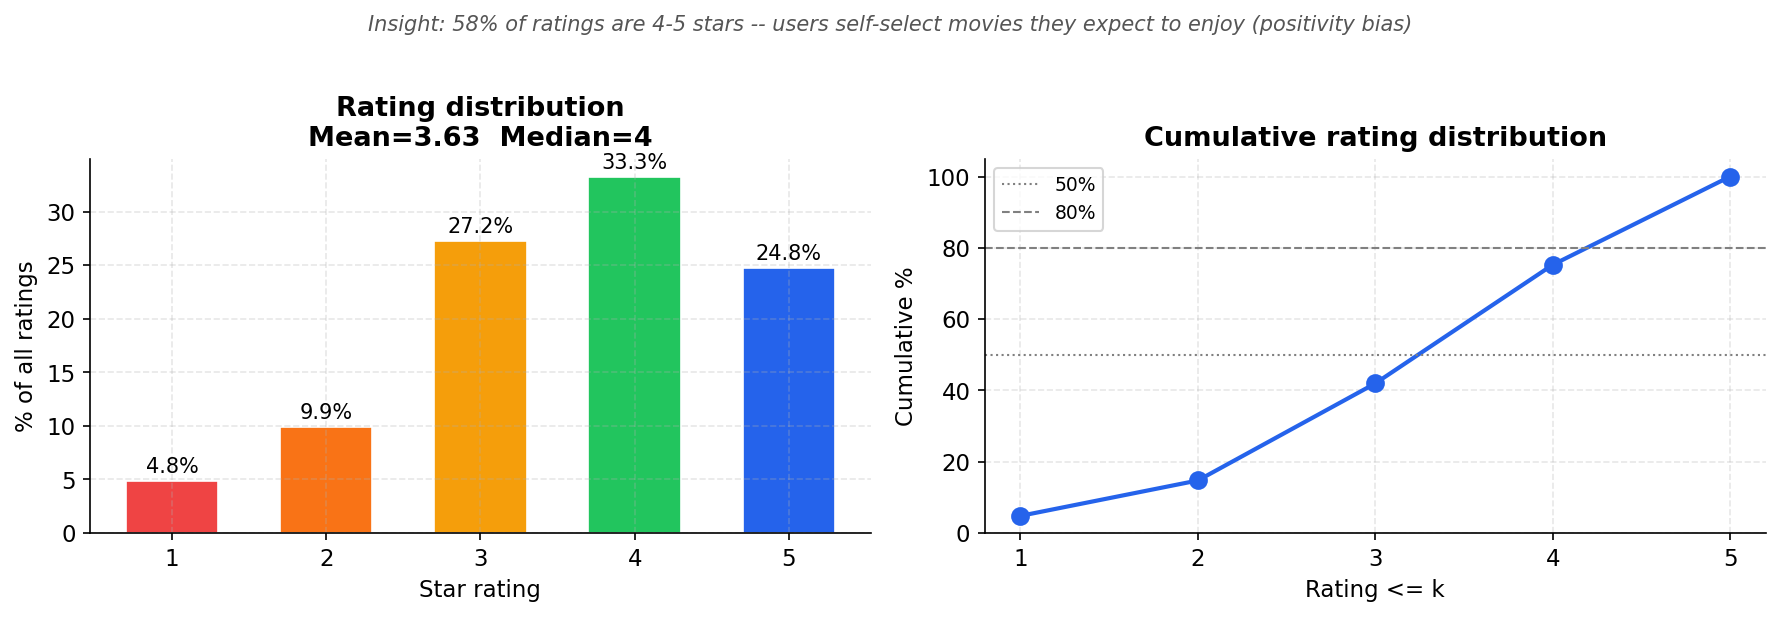

  → saved ./outputs/figures\02_rating_distribution.png
  4-5 star: 58.0%   1-2 star: 14.8%   mean: 3.632



In [22]:

#  §2 — RATING DISTRIBUTION
print("Section 2: Rating distribution")

r_counts = full_df['rating'].value_counts().sort_index()
r_pct    = r_counts / N_RATINGS * 100
pct_4_5  = r_pct.loc[r_pct.index >= 4].sum()
pct_1_2  = r_pct.loc[r_pct.index <= 2].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
C = ['#2563EB', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6']
bar_colors = ['#EF4444', '#F97316', '#F59E0B', '#22C55E', '#2563EB']
bars = axes[0].bar(r_counts.index, r_pct.values, color=bar_colors,
                   edgecolor='white', lw=0.8, width=0.6)
for bar, v in zip(bars, r_pct.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
axes[0].set(xlabel='Star rating', ylabel='% of all ratings',
            title=f'Rating distribution\nMean={GLOBAL_MEAN:.2f}  Median={full_df["rating"].median():.0f}',
            xticks=[1, 2, 3, 4, 5])

cum = r_pct.cumsum()
axes[1].plot(cum.index, cum.values, 'o-', color=C[0], lw=2, ms=8)
for y_val, ls, lbl in [(50, ':', '50%'), (80, '--', '80%')]:
    axes[1].axhline(y_val, color='gray', linestyle=ls, lw=1, label=lbl)
axes[1].set(xlabel='Rating <= k', ylabel='Cumulative %',
            title='Cumulative rating distribution',
            xticks=[1, 2, 3, 4, 5], ylim=(0, 105))
axes[1].legend(fontsize=9)
fig.suptitle(f'Insight: {pct_4_5:.0f}% of ratings are 4-5 stars -- '
             f'users self-select movies they expect to enjoy (positivity bias)',
             fontsize=10, style='italic', y=1.02, color='#555')
plt.tight_layout()
display(fig)
save(fig, '02_rating_distribution.png')
print(f"  4-5 star: {pct_4_5:.1f}%   1-2 star: {pct_1_2:.1f}%   mean: {GLOBAL_MEAN:.3f}\n")


Section 3: User activity & cold start  [merged]
  → saved ./outputs/figures\03_user_activity_coldstart.png


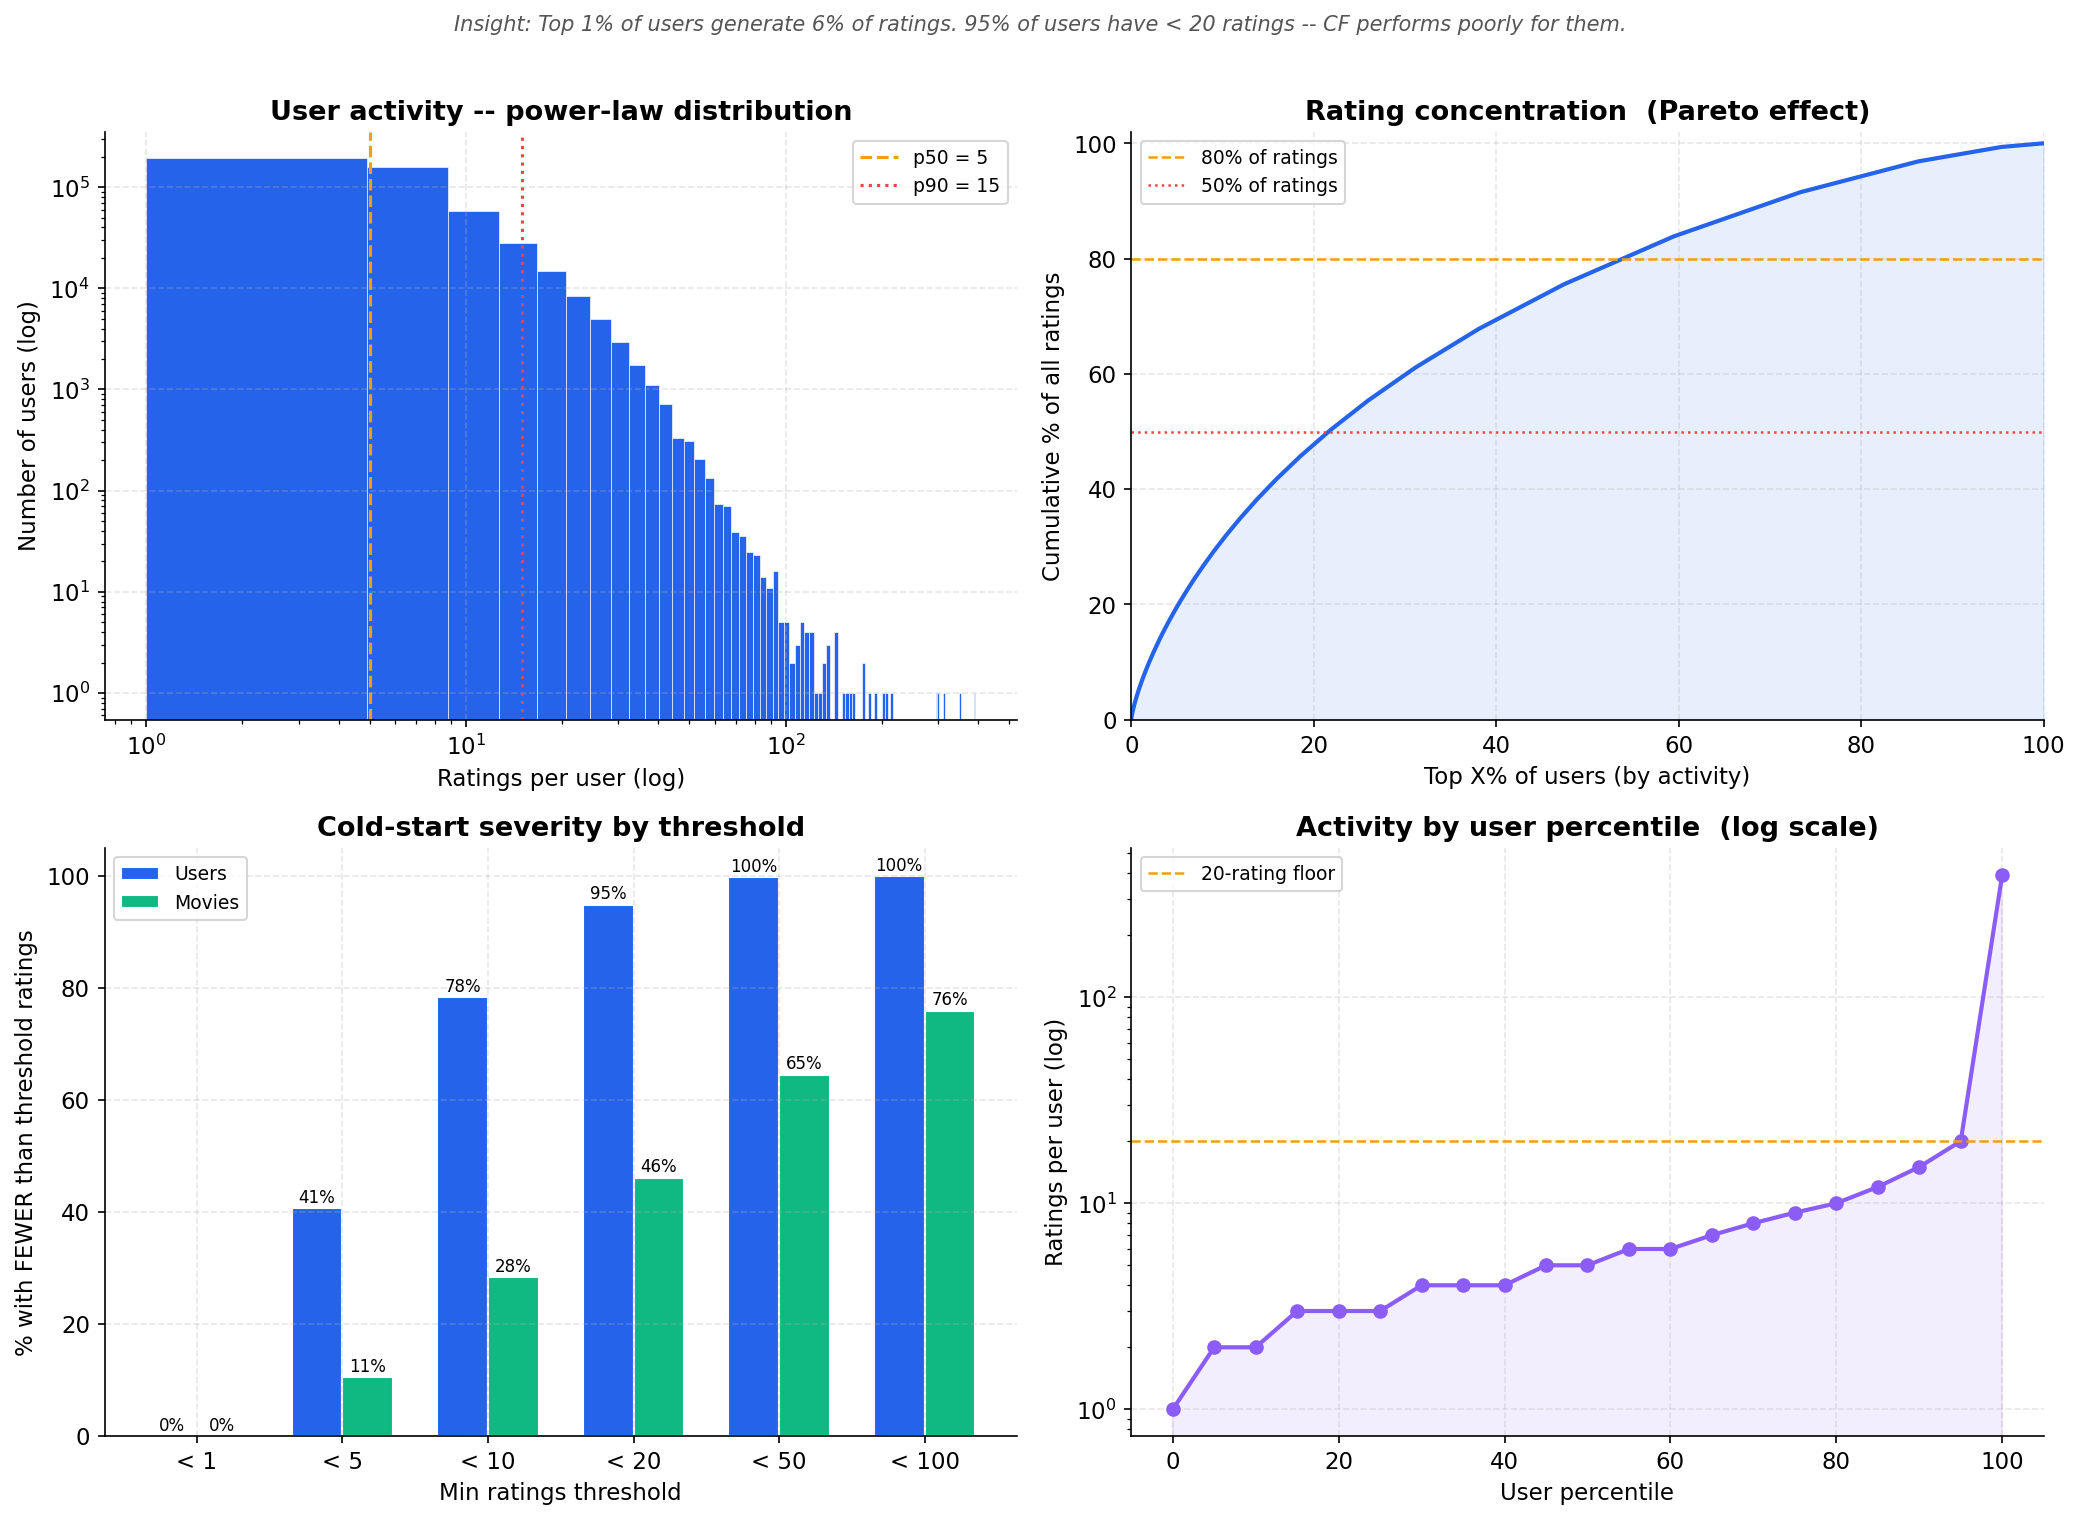

  top-1% share: 6.2%   users < 20 ratings: 94.9%



In [23]:
#  §3 — USER ACTIVITY & COLD START 
print("Section 3: User activity & cold start  [merged]")

top1_thr      = user_activity.quantile(0.99)
top1_share    = user_activity[user_activity >= top1_thr].sum() / N_RATINGS * 100
pct_lt20      = (user_activity < 20).mean() * 100
thresholds    = [1, 5, 10, 20, 50, 100]
user_cold     = [(user_activity < t).mean() * 100 for t in thresholds]
movie_cold    = [(movie_stats['n_ratings'] < t).mean() * 100 for t in thresholds]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (0,0) Activity histogram log-log
axes[0, 0].hist(user_activity, bins=100, color=C[0], edgecolor='white', lw=0.3)
axes[0, 0].set_xscale('log')
axes[0, 0].set_yscale('log')
axes[0, 0].set(xlabel='Ratings per user (log)', ylabel='Number of users (log)',
               title='User activity -- power-law distribution')
for q, col, ls in [(0.5, C[2], '--'), (0.9, C[3], ':')]:
    v = user_activity.quantile(q)
    axes[0, 0].axvline(v, color=col, linestyle=ls, lw=1.5,
                       label=f'p{int(q*100)} = {int(v)}')
axes[0, 0].legend(fontsize=9)

# (0,1) Pareto concentration
sorted_u  = user_activity.sort_values(ascending=False)
cum_share = sorted_u.cumsum() / N_RATINGS * 100
rank_pct  = np.linspace(0, 100, len(cum_share))
axes[0, 1].plot(rank_pct, cum_share.values, color=C[0], lw=2)
axes[0, 1].fill_between(rank_pct, cum_share.values, alpha=0.1, color=C[0])
for y_val, col, ls, lbl in [(80, C[2], '--', '80% of ratings'),
                              (50, C[3], ':',  '50% of ratings')]:
    axes[0, 1].axhline(y_val, color=col, linestyle=ls, lw=1.2, label=lbl)
axes[0, 1].set(xlabel='Top X% of users (by activity)',
               ylabel='Cumulative % of all ratings',
               title='Rating concentration  (Pareto effect)',
               xlim=(0, 100), ylim=(0, 102))
axes[0, 1].legend(fontsize=9)

# (1,0) Cold-start grouped bar
x = np.arange(len(thresholds))
w = 0.35
axes[1, 0].bar(x - w/2, user_cold,  w, label='Users',  color=C[0], edgecolor='white')
axes[1, 0].bar(x + w/2, movie_cold, w, label='Movies', color=C[1], edgecolor='white')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels([f'< {t}' for t in thresholds])
axes[1, 0].set(xlabel='Min ratings threshold',
               ylabel='% with FEWER than threshold ratings',
               title='Cold-start severity by threshold')
axes[1, 0].legend(fontsize=9)
for i, (u, m) in enumerate(zip(user_cold, movie_cold)):
    axes[1, 0].text(i - w/2, u + 1.0, f'{u:.0f}%', ha='center', fontsize=8)
    axes[1, 0].text(i + w/2, m + 1.0, f'{m:.0f}%', ha='center', fontsize=8)

# (1,1) Activity by percentile log
qs = [user_activity.quantile(p / 100) for p in range(0, 101, 5)]
axes[1, 1].plot(range(0, 101, 5), qs, 'o-', color=C[4], lw=2, ms=6)
axes[1, 1].fill_between(range(0, 101, 5), qs, alpha=0.1, color=C[4])
axes[1, 1].set_yscale('log')
axes[1, 1].axhline(20, color=C[2], linestyle='--', lw=1.2, label='20-rating floor')
axes[1, 1].set(xlabel='User percentile', ylabel='Ratings per user (log)',
               title='Activity by user percentile  (log scale)')
axes[1, 1].legend(fontsize=9)

fig.suptitle(f'Insight: Top 1% of users generate {top1_share:.0f}% of ratings. '
             f'{pct_lt20:.0f}% of users have < 20 ratings -- '
             f'CF performs poorly for them.',
             fontsize=10, style='italic', y=1.01, color='#555')
plt.tight_layout()
save(fig, '03_user_activity_coldstart.png')
display(fig)
print(f"  top-1% share: {top1_share:.1f}%   users < 20 ratings: {pct_lt20:.1f}%\n")


Section 4: Movie popularity & concentration
  → saved ./outputs/figures\04_movie_concentration.png


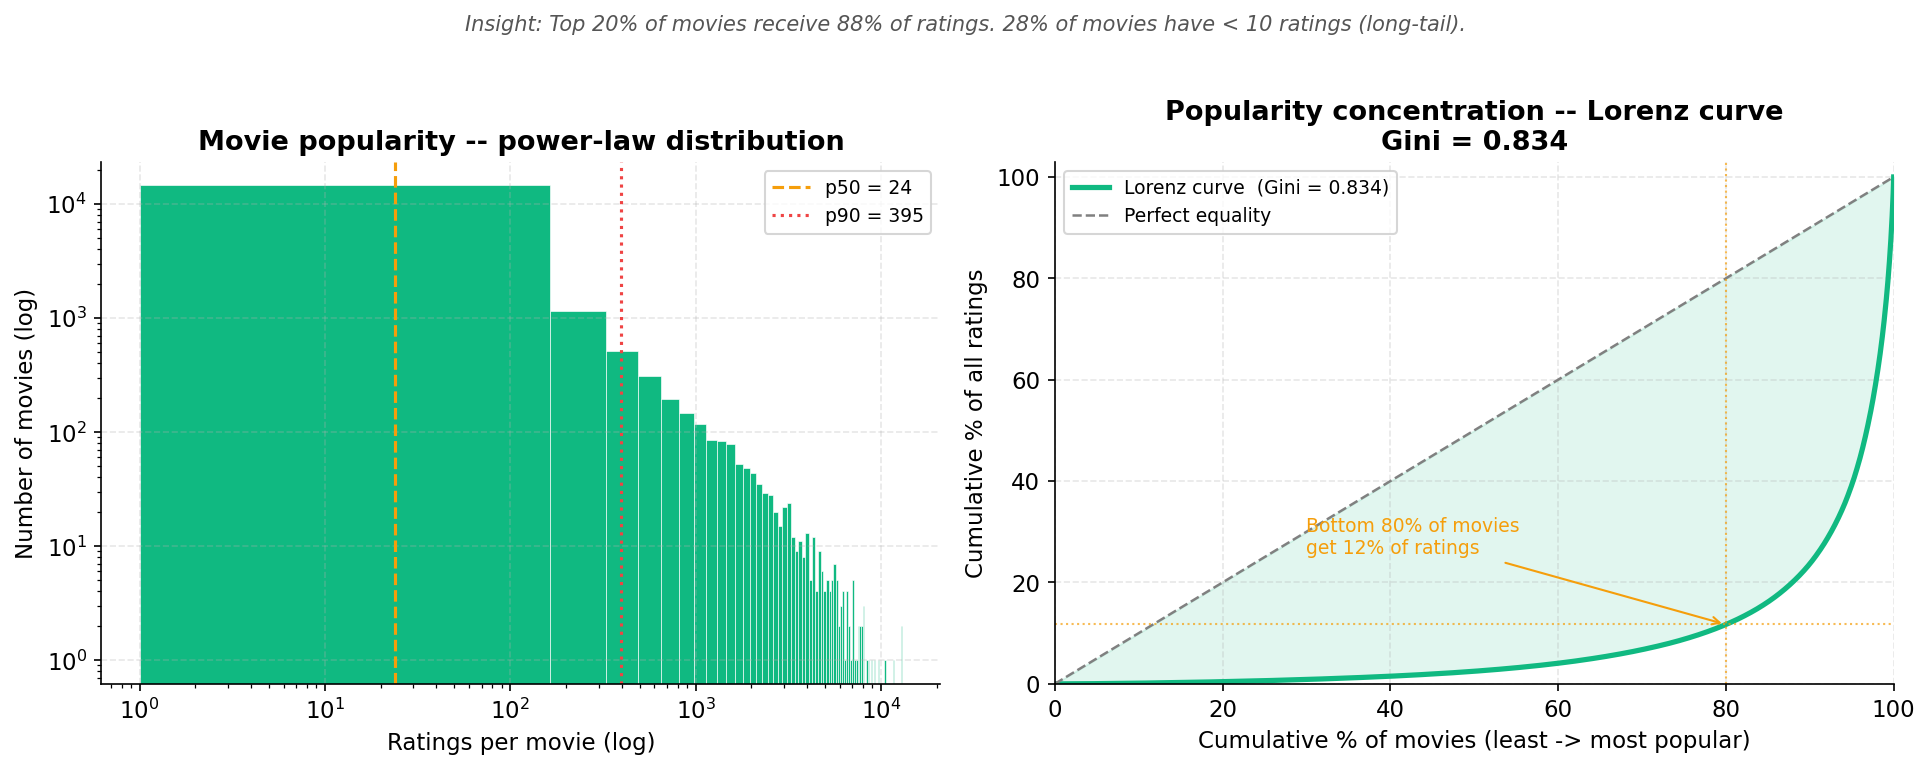

  Gini=0.834   top-20% share: 88%   cold (<10 ratings): 28%



In [24]:


# =====================================================================
#  §4 — MOVIE POPULARITY & CONCENTRATION  (histogram + Lorenz)
# =====================================================================
print("Section 4: Movie popularity & concentration")

cold_movies = (movie_stats['n_ratings'] < 10).mean() * 100

sorted_n = np.sort(movie_stats['n_ratings'].values).astype(float)
n_m      = len(sorted_n)
lx = np.concatenate([[0], np.arange(1, n_m + 1) / n_m * 100])
ly = np.concatenate([[0], np.cumsum(sorted_n) / sorted_n.sum() * 100])
gini     = 1 - 2 * np.trapezoid(ly / 100, lx / 100)
idx_80   = min(np.searchsorted(lx, 80), len(ly) - 1)
top20_pct = 100 - ly[idx_80]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(movie_stats['n_ratings'], bins=80, color=C[1], edgecolor='white', lw=0.3)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set(xlabel='Ratings per movie (log)', ylabel='Number of movies (log)',
            title='Movie popularity -- power-law distribution')
for q, col, ls in [(0.5, C[2], '--'), (0.9, C[3], ':')]:
    v = movie_stats['n_ratings'].quantile(q)
    axes[0].axvline(v, color=col, linestyle=ls, lw=1.5,
                    label=f'p{int(q*100)} = {int(v)}')
axes[0].legend(fontsize=9)

axes[1].plot(lx, ly, color=C[1], lw=2.5,
             label=f'Lorenz curve  (Gini = {gini:.3f})')
axes[1].plot([0, 100], [0, 100], '--', color='gray', lw=1.2, label='Perfect equality')
axes[1].fill_between(lx, ly, lx, alpha=0.12, color=C[1])
axes[1].axvline(80, color=C[2], linestyle=':', lw=1, alpha=0.7)
axes[1].axhline(ly[idx_80], color=C[2], linestyle=':', lw=1, alpha=0.7)
if ly[idx_80] < 70:
    axes[1].annotate(f'Bottom 80% of movies\nget {ly[idx_80]:.0f}% of ratings',
                     xy=(80, ly[idx_80]), xytext=(30, ly[idx_80] + 14),
                     arrowprops=dict(arrowstyle='->', color=C[2]),
                     fontsize=9, color=C[2])
axes[1].set(xlabel='Cumulative % of movies (least -> most popular)',
            ylabel='Cumulative % of all ratings',
            title=f'Popularity concentration -- Lorenz curve\nGini = {gini:.3f}',
            xlim=(0, 100), ylim=(0, 103))
axes[1].legend(fontsize=9)

fig.suptitle(f'Insight: Top 20% of movies receive {top20_pct:.0f}% of ratings. '
             f'{cold_movies:.0f}% of movies have < 10 ratings (long-tail).',
             fontsize=10, style='italic', y=1.02, color='#555')
plt.tight_layout()
save(fig, '04_movie_concentration.png')
display(fig)
print(f"  Gini={gini:.3f}   top-20% share: {top20_pct:.0f}%   "
      f"cold (<10 ratings): {cold_movies:.0f}%\n")



Section 5: Temporal trends
  → saved ./outputs/figures\05_temporal_trends.png


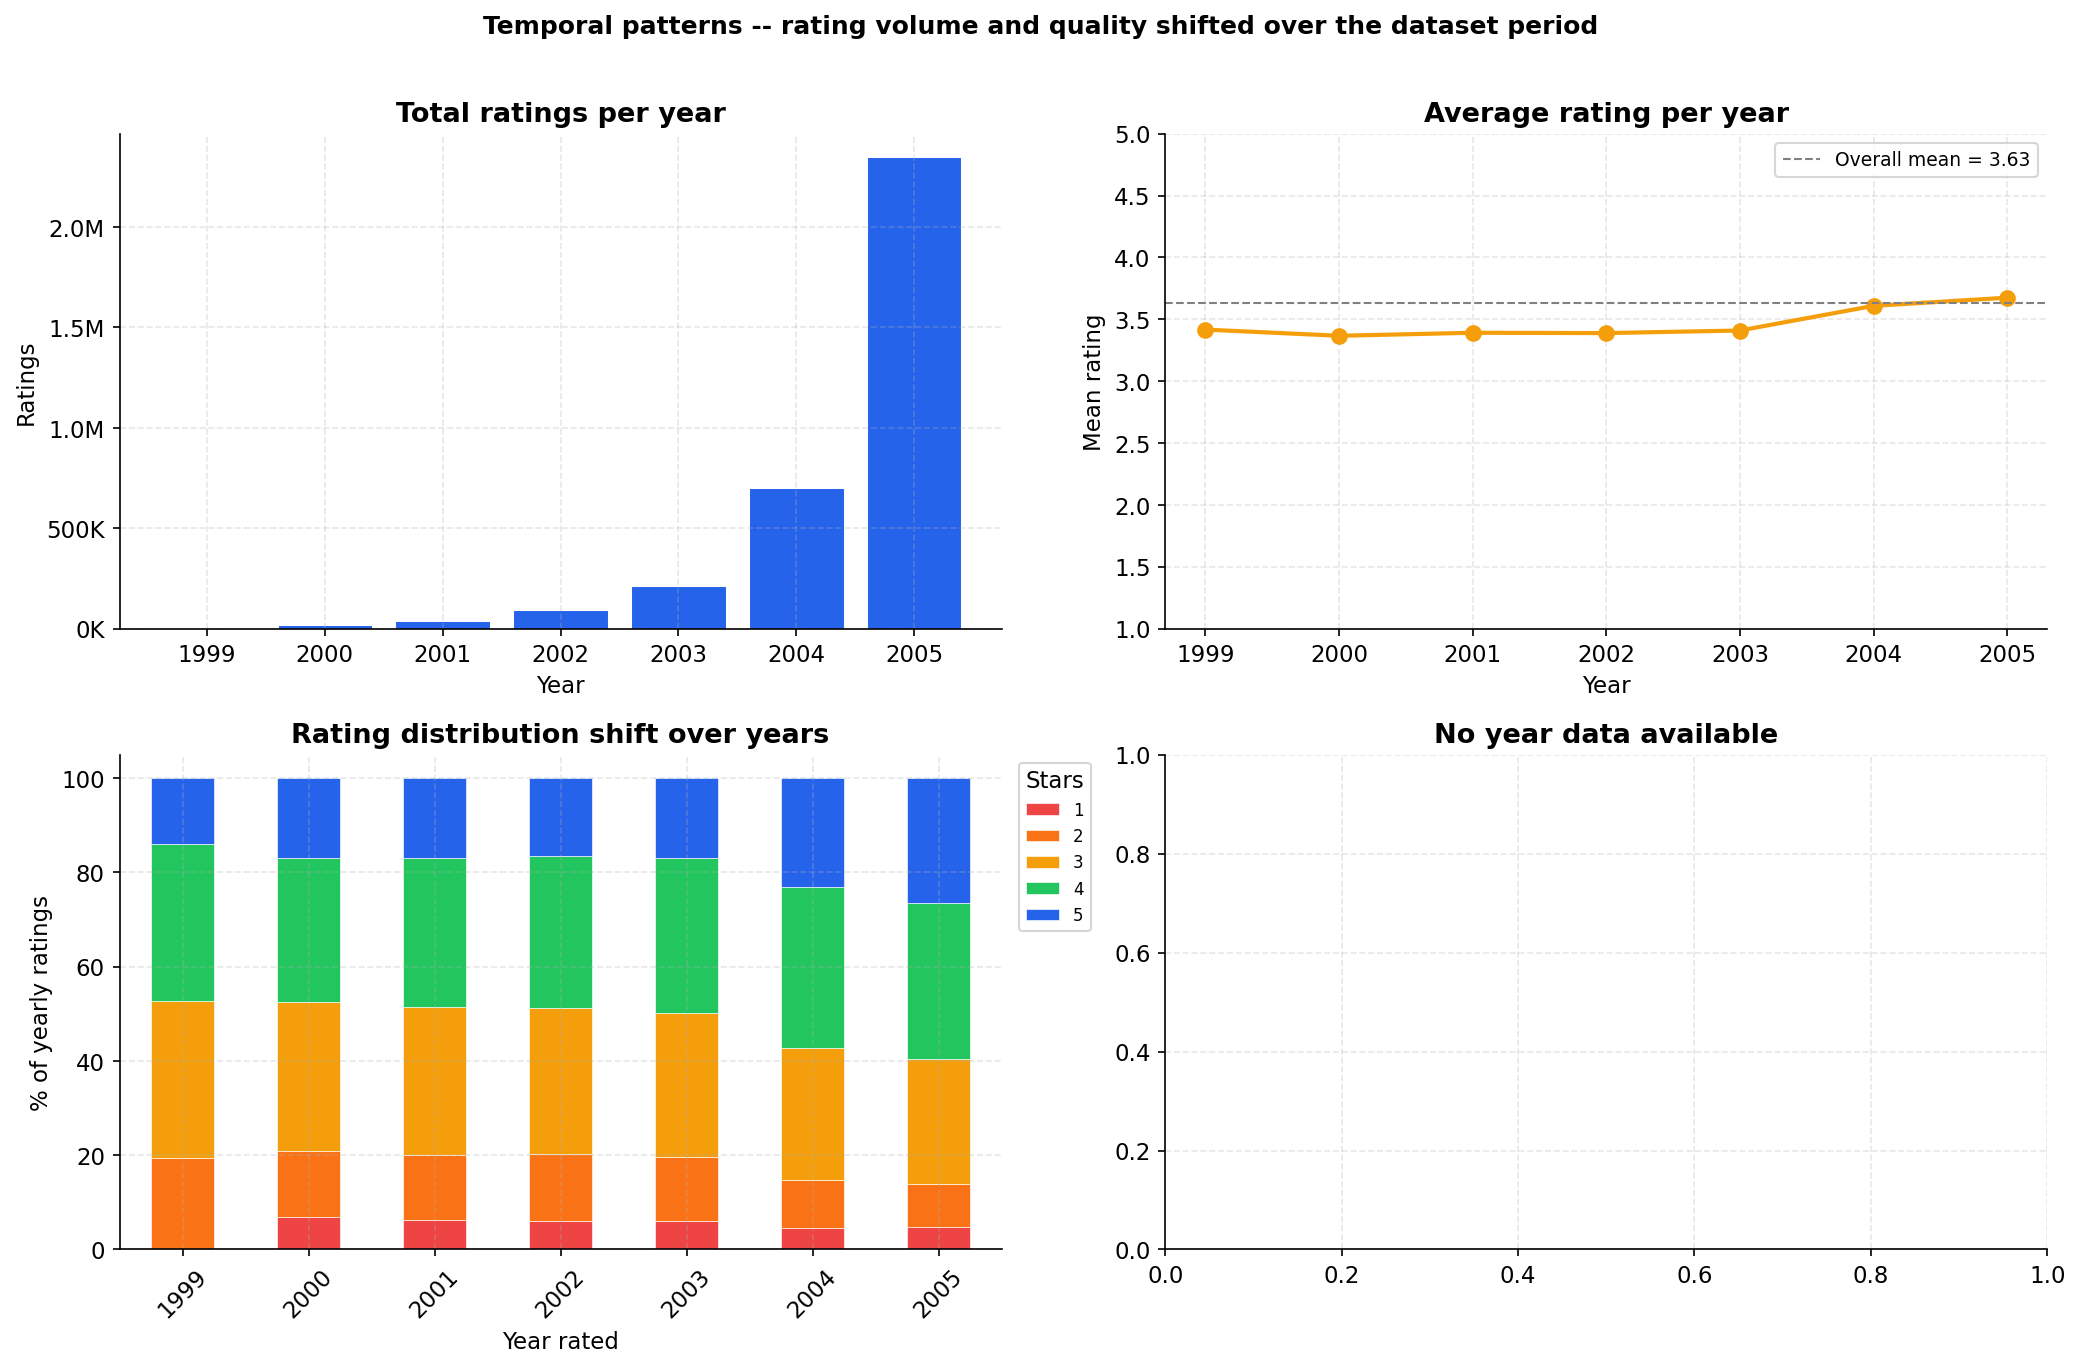

  year range: 1999-2005   peak year: 2005



In [25]:
#  §5 — TEMPORAL TRENDS
print("Section 5: Temporal trends")

ratings_by_year = full_df.groupby('year_rated').size()
avg_by_year     = full_df.groupby('year_rated')['rating'].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].bar(ratings_by_year.index, ratings_by_year.values,
               color=C[0], edgecolor='white', lw=0.5)
axes[0, 0].set(xlabel='Year', ylabel='Ratings', title='Total ratings per year')
axes[0, 0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))

axes[0, 1].plot(avg_by_year.index, avg_by_year.values, 'o-', color=C[2], lw=2, ms=7)
axes[0, 1].axhline(GLOBAL_MEAN, color='gray', linestyle='--', lw=1,
                   label=f'Overall mean = {GLOBAL_MEAN:.2f}')
axes[0, 1].set(xlabel='Year', ylabel='Mean rating',
               title='Average rating per year', ylim=(1, 5))
axes[0, 1].legend(fontsize=9)

yr_rat = full_df.groupby(['year_rated', 'rating']).size().unstack(fill_value=0)
if yr_rat.shape[0] > 1:
    yr_pct = yr_rat.div(yr_rat.sum(axis=1), axis=0) * 100
    yr_pct.plot(kind='bar', stacked=True, ax=axes[1, 0],
                color=['#EF4444', '#F97316', '#F59E0B', '#22C55E', '#2563EB'],
                edgecolor='white', lw=0.3, legend=False)
    axes[1, 0].set(xlabel='Year rated', ylabel='% of yearly ratings',
                   title='Rating distribution shift over years')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].legend(title='Stars', bbox_to_anchor=(1.01, 1), fontsize=8)
else:
    axes[1, 0].text(0.5, 0.5, 'Needs multiple years\n(will populate on full data)',
                    ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('Rating shift (needs full data)')

if 'year' in full_df.columns and full_df['year'].notna().any():
    full_df['movie_age'] = full_df['year_rated'] - full_df['year'].astype(float)
    age_data = (full_df[full_df['movie_age'].between(0, 20)]
                .groupby('movie_age')['rating'].agg(['mean', 'count']))
    if len(age_data) > 1:
        axes[1, 1].plot(age_data.index, age_data['mean'], 'o-',
                        color=C[3], lw=2, ms=5)
        axes[1, 1].fill_between(age_data.index,
                                 age_data['mean'] - 0.1,
                                 age_data['mean'] + 0.1,
                                 alpha=0.15, color=C[3])
        axes[1, 1].set(xlabel='Years since movie release', ylabel='Mean rating',
                       title='Average rating vs movie age', ylim=(1, 5))
    else:
        axes[1, 1].text(0.5, 0.5, 'Needs wider age range',
                        ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Rating vs movie age')
else:
    axes[1, 1].set_title('No year data available')

plt.suptitle('Temporal patterns -- rating volume and quality shifted over the dataset period',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
save(fig, '05_temporal_trends.png')
display(fig)
print(f"  year range: {full_df['year_rated'].min()}-{full_df['year_rated'].max()}   "
      f"peak year: {ratings_by_year.idxmax()}\n")



Section 6: Movie release year analysis  [new in v2]
  → saved ./outputs/figures\06_release_year_analysis.png


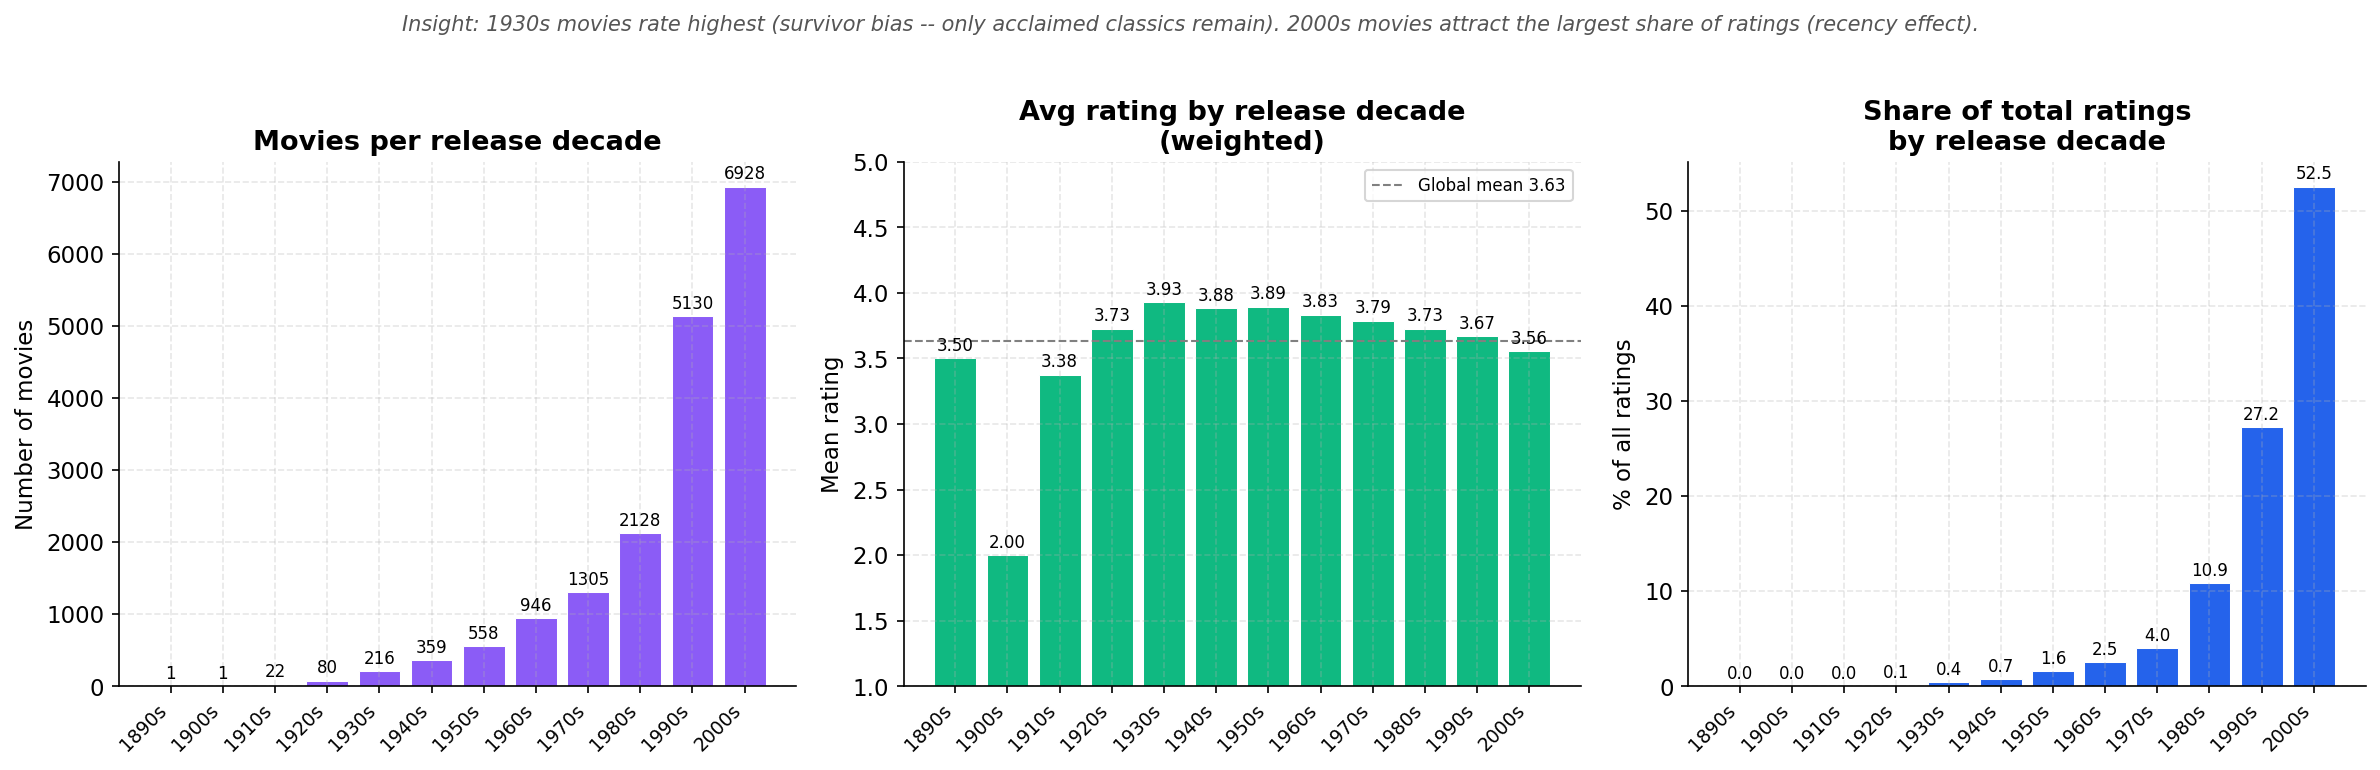

  decades covered: 12   highest-rated decade: 1930s



In [26]:

# =====================================================================
#  §6 — MOVIE RELEASE YEAR ANALYSIS  (new section)
# =====================================================================
print("Section 6: Movie release year analysis  [new in v2]")

ms_yr = movie_stats.dropna(subset=['year']).copy()
ms_yr['decade'] = (ms_yr['year'].astype(float).astype(int) // 10 * 10)

movies_per_decade = ms_yr.groupby('decade').size()
decade_avg = (
    ms_yr.groupby('decade')
    .apply(lambda g: np.average(g['avg_rating'], weights=g['n_ratings']))
    .rename('w_avg')
)
decade_share = ms_yr.groupby('decade')['n_ratings'].sum() / ms_yr['n_ratings'].sum() * 100

all_decades   = sorted(set(movies_per_decade.index) | set(decade_avg.index))
decade_labels = [f"{int(d)}s" for d in all_decades]

def _decade_bar(ax, series, color, title, ylabel, fmt='{:.0f}', ylim=None):
    vals = [series.get(d, 0) for d in all_decades]
    bars = ax.bar(range(len(all_decades)), vals, color=color,
                  edgecolor='white', lw=0.5)
    ax.set_xticks(range(len(all_decades)))
    ax.set_xticklabels(decade_labels, rotation=45, ha='right', fontsize=9)
    ax.set(title=title, ylabel=ylabel)
    if ylim:
        ax.set_ylim(ylim)
    max_v = max(vals) if any(v > 0 for v in vals) else 1
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max_v * 0.015,
                    fmt.format(v), ha='center', fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
_decade_bar(axes[0], movies_per_decade, C[4],
            'Movies per release decade',                 'Number of movies', '{:.0f}')
_decade_bar(axes[1], decade_avg,        C[1],
            'Avg rating by release decade\n(weighted)', 'Mean rating',       '{:.2f}',
            ylim=(1, 5))
axes[1].axhline(GLOBAL_MEAN, color='gray', linestyle='--', lw=1,
                label=f'Global mean {GLOBAL_MEAN:.2f}')
axes[1].legend(fontsize=8)
_decade_bar(axes[2], decade_share, C[0],
            'Share of total ratings\nby release decade', '% of all ratings', '{:.1f}')

if len(decade_avg) >= 2:
    top_q  = int(decade_avg.idxmax())
    top_v  = int(decade_share.idxmax())
    insight = (f'Insight: {top_q}s movies rate highest (survivor bias -- '
               f'only acclaimed classics remain). '
               f'{top_v}s movies attract the largest share of ratings (recency effect).')
else:
    insight = 'Insight: needs full dataset to reveal decade-level patterns.'

fig.suptitle(insight, fontsize=10, style='italic', y=1.02, color='#555')
plt.tight_layout()
save(fig, '06_release_year_analysis.png')
top_str = f"{int(decade_avg.idxmax())}s" if len(decade_avg) else 'N/A'
display(fig)
print(f"  decades covered: {len(all_decades)}   highest-rated decade: {top_str}\n")



Section 7: User & movie bias
  → saved ./outputs/figures\07_rating_bias.png


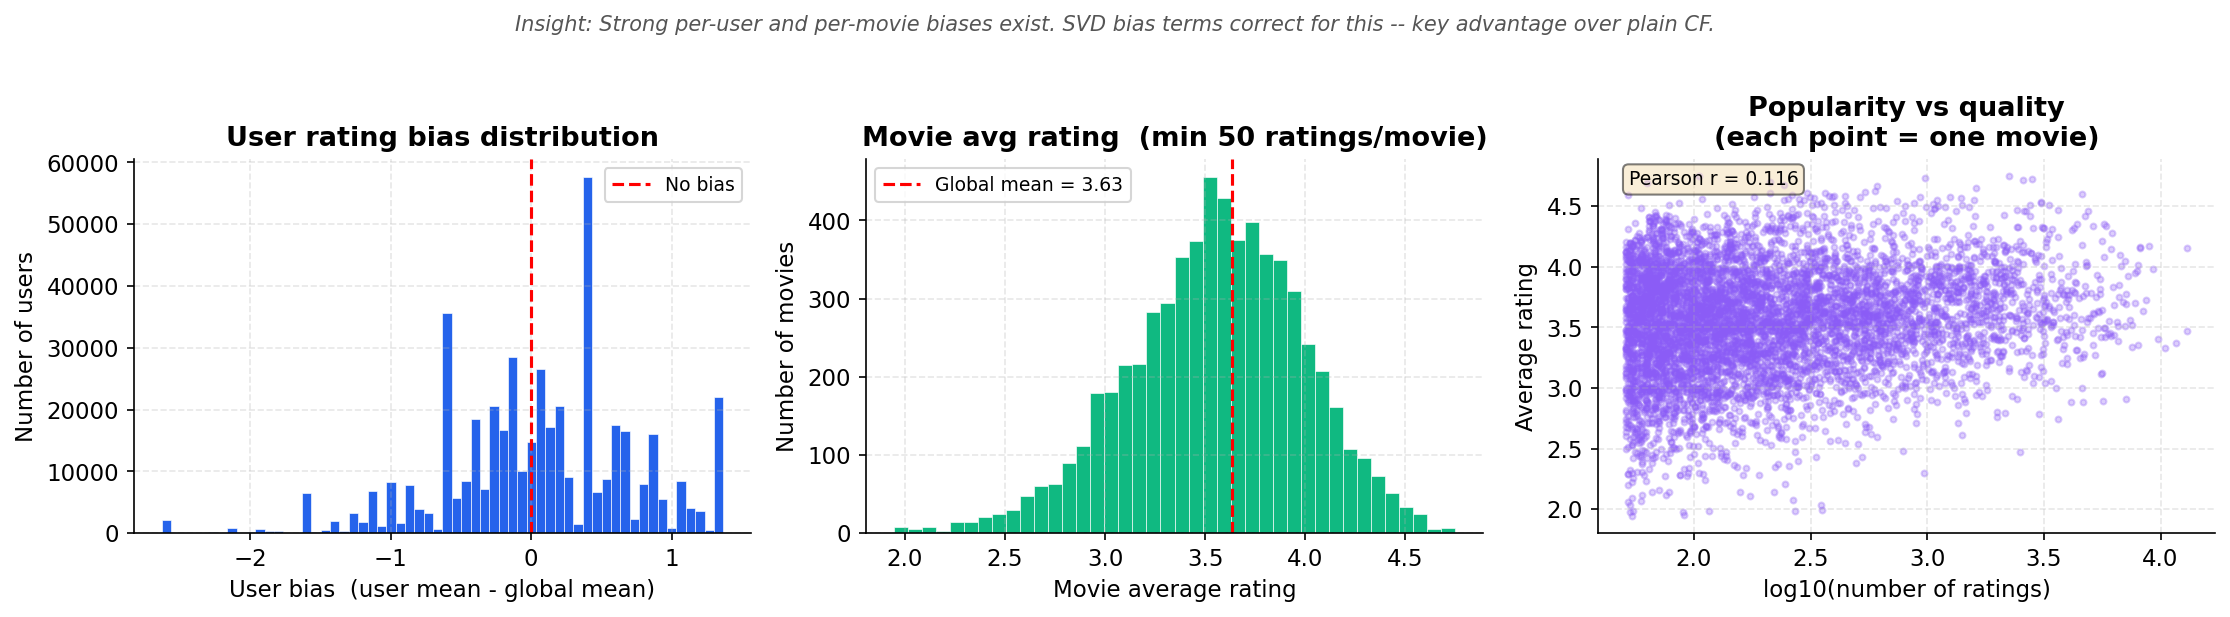

  user bias std: 0.690   popularity-quality corr: 0.116



In [27]:
#  §7 — USER & MOVIE BIAS  (uses pre-computed movie_stats)
print("Section 7: User & movie bias")

MIN_R    = max(50, int(movie_stats['n_ratings'].quantile(0.25)))
reliable = movie_stats[movie_stats['n_ratings'] >= MIN_R]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(user_bias, bins=60, color=C[0], edgecolor='white', lw=0.3)
axes[0].axvline(0, color='red', linestyle='--', lw=1.5, label='No bias')
axes[0].set(xlabel='User bias  (user mean - global mean)', ylabel='Number of users',
            title='User rating bias distribution')
axes[0].legend(fontsize=9)

if len(reliable) > 0:
    axes[1].hist(reliable['avg_rating'], bins=40, color=C[1], edgecolor='white', lw=0.3)
    axes[1].axvline(GLOBAL_MEAN, color='red', linestyle='--', lw=1.5,
                    label=f'Global mean = {GLOBAL_MEAN:.2f}')
    axes[1].set(xlabel='Movie average rating', ylabel='Number of movies',
                title=f'Movie avg rating  (min {MIN_R} ratings/movie)')
    axes[1].legend(fontsize=9)

    corr = reliable['n_ratings'].corr(reliable['avg_rating'])
    axes[2].scatter(np.log10(reliable['n_ratings'] + 1), reliable['avg_rating'],
                    alpha=0.3, s=8, color=C[4])
    axes[2].text(0.05, 0.93, f'Pearson r = {corr:.3f}', transform=axes[2].transAxes,
                 fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[2].set(xlabel='log10(number of ratings)', ylabel='Average rating',
                title='Popularity vs quality\n(each point = one movie)')
else:
    corr = float('nan')
    for ax in axes[1:]:
        ax.text(0.5, 0.5, 'Needs more data', ha='center', va='center',
                transform=ax.transAxes)

fig.suptitle('Insight: Strong per-user and per-movie biases exist. '
             'SVD bias terms correct for this -- key advantage over plain CF.',
             fontsize=10, style='italic', y=1.02, color='#555')
plt.tight_layout()
save(fig, '07_rating_bias.png')
display(fig)
print(f"  user bias std: {user_bias.std():.3f}   "
      f"popularity-quality corr: {corr:.3f}\n")


Section 8: Top / bottom / most divisive movies
  → saved ./outputs/figures\08_movie_quality.png


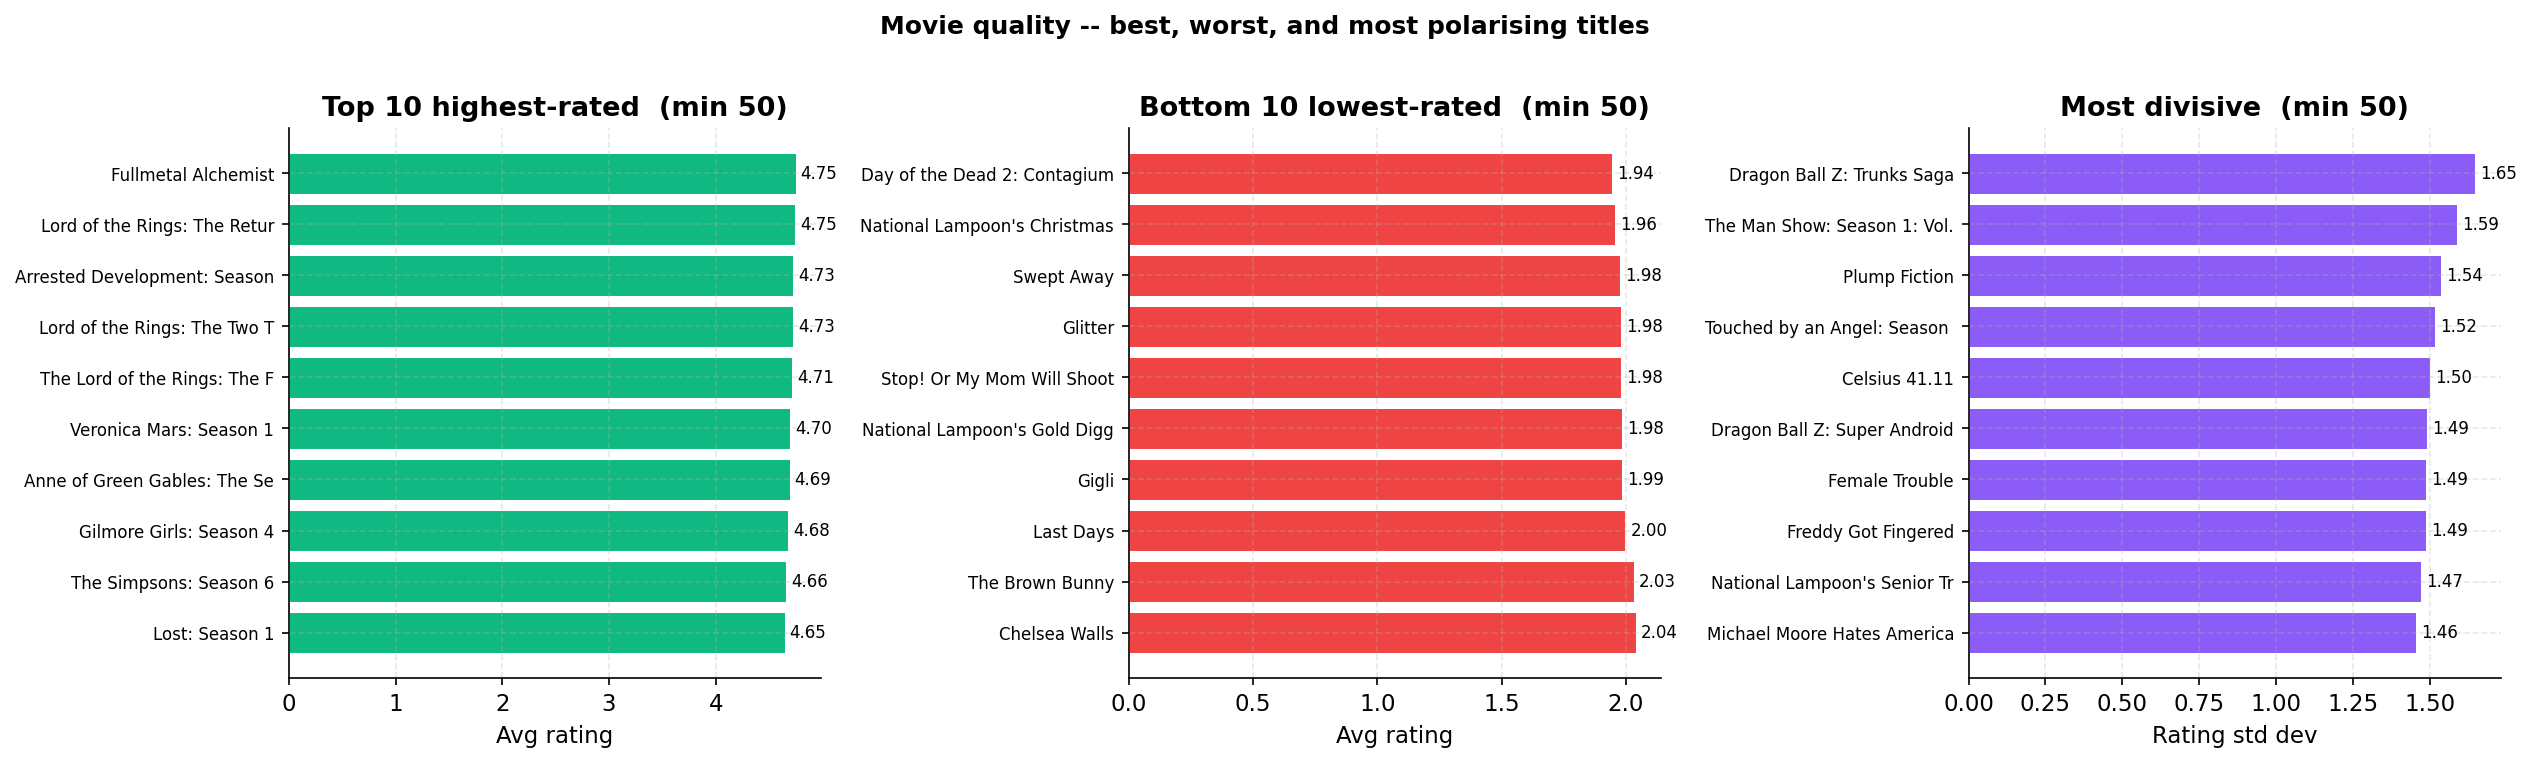

  highest: 4.750   lowest: 1.943   most divisive std: 1.648



In [28]:
#  §8 — TOP / BOTTOM / MOST DIVISIVE  (uses pre-computed movie_stats)
print("Section 8: Top / bottom / most divisive movies")

MIN_N  = max(50, int(movie_stats['n_ratings'].quantile(0.6)))
pool   = movie_stats[movie_stats['n_ratings'] >= MIN_N].copy()
K      = min(10, max(1, len(pool)))
top_df = pool.nlargest(K, 'avg_rating')
bot_df = pool.nsmallest(K, 'avg_rating')
div_df = (pool[pool['std_rating'].notna()].nlargest(K, 'std_rating')
          if pool['std_rating'].notna().any() else pool.head(K))


def _hbar(ax, df, col, color, title, xlabel):
    vals = df[col].values
    labs = [str(t)[:28] for t in df['title'].fillna('Unknown').values]
    n    = len(vals)
    ax.barh(range(n), vals[::-1], color=color, edgecolor='white', lw=0.5)
    ax.set_yticks(range(n))
    ax.set_yticklabels(labs[::-1], fontsize=8)
    ax.set(title=title, xlabel=xlabel)
    off = max(vals) * 0.01 if len(vals) else 0.05
    for i, v in enumerate(vals[::-1]):
        ax.text(v + off, i, f'{v:.2f}', va='center', fontsize=8)


fig, axes = plt.subplots(1, 3, figsize=(17, 5))
_hbar(axes[0], top_df, 'avg_rating', C[1],
      f'Top {K} highest-rated  (min {MIN_N})',   'Avg rating')
_hbar(axes[1], bot_df, 'avg_rating', C[3],
      f'Bottom {K} lowest-rated  (min {MIN_N})', 'Avg rating')
_hbar(axes[2], div_df, 'std_rating', C[4],
      f'Most divisive  (min {MIN_N})',            'Rating std dev')

plt.suptitle('Movie quality -- best, worst, and most polarising titles',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
save(fig, '08_movie_quality.png')
display(fig)
print(f"  highest: {top_df['avg_rating'].max():.3f}   "
      f"lowest: {bot_df['avg_rating'].min():.3f}   "
      f"most divisive std: {div_df['std_rating'].max():.3f}\n")


In [29]:
#  §9 — KEY INSIGHTS SUMMARY
print("Section 9: Key insights summary")

summary_lines = [
    "  NETFLIX PRIZE EDA -- KEY INSIGHTS SUMMARY (v2)",
    "DATASET",
    f"  {N_RATINGS:>12,} ratings | {N_USERS:,} users | {N_MOVIES:,} movies",
    f"  Fill rate {FILL_PCT:.4f}% -- matrix is {SPARSITY:.2f}% sparse",
    f"  Avg {N_RATINGS/N_USERS:.0f} ratings/user | {N_RATINGS/N_MOVIES:.0f} ratings/movie",
    "",
    "RATING SKEW  (positivity / self-selection bias)",
    f"  {pct_4_5:.1f}% of ratings are 4-5 stars | only {pct_1_2:.1f}% are 1-2 stars",
    f"  Global mean = {GLOBAL_MEAN:.2f}  (well above neutral 3.0)",
    "  Implication: threshold >= 3.5 captures genuine positive signal",
    "",
    "POWER-LAW DISTRIBUTIONS",
    f"  Top 1% of users contribute {top1_share:.0f}% of all ratings",
    f"  Top 20% of movies receive {top20_pct:.0f}% of all ratings",
    f"  Movie popularity Gini coefficient = {gini:.3f}  (severe concentration)",
    f"  {cold_movies:.0f}% of movies have < 10 ratings  (long-tail cold-start)",
    "",
    "COLD START",
    f"  {pct_lt20:.0f}% of users have < 20 training ratings  (CF unreliable)",
    "  Fallback strategy: popularity-based recommendations for cold users",
    "",
    "USER & MOVIE BIAS",
    f"  User rating tendencies vary widely (sigma = {user_bias.std():.2f} stars)",
    "  SVD bias terms directly correct for this -- key advantage over plain CF",
    "",
    "RELEASE YEAR PATTERNS",
    "  Classic movies score higher on average (survivor bias)",
    "  Recent-era movies receive the largest share of ratings (recency effect)",
    "",
    "MODEL IMPLICATIONS",
    "  1. SVD preferred over plain CF due to explicit bias correction",
    "  2. Item-CF benefits from long-tail films (explainability)",
    f"  3. Cold-start users (~{pct_lt20:.0f}%) need a popularity fallback",
    "  4. Temporal recency improves MAP@10 ranking quality",
]

summary = "\n".join(summary_lines)
print(summary)

with open(SUMMARY_PATH, 'w') as f:
    f.write(summary)
print(f"\nSummary saved to {SUMMARY_PATH}")
print(f"\n{'='*55}")
print("  EDA v2 COMPLETE -- 8 figures in ./outputs/figures/")

Section 9: Key insights summary
  NETFLIX PRIZE EDA -- KEY INSIGHTS SUMMARY (v2)
DATASET
     3,408,342 ratings | 471,830 users | 17,681 movies
  Fill rate 0.0409% -- matrix is 99.96% sparse
  Avg 7 ratings/user | 193 ratings/movie

RATING SKEW  (positivity / self-selection bias)
  58.0% of ratings are 4-5 stars | only 14.8% are 1-2 stars
  Global mean = 3.63  (well above neutral 3.0)
  Implication: threshold >= 3.5 captures genuine positive signal

POWER-LAW DISTRIBUTIONS
  Top 1% of users contribute 6% of all ratings
  Top 20% of movies receive 88% of all ratings
  Movie popularity Gini coefficient = 0.834  (severe concentration)
  28% of movies have < 10 ratings  (long-tail cold-start)

COLD START
  95% of users have < 20 training ratings  (CF unreliable)
  Fallback strategy: popularity-based recommendations for cold users

USER & MOVIE BIAS
  User rating tendencies vary widely (sigma = 0.69 stars)
  SVD bias terms directly correct for this -- key advantage over plain CF

RELEASE YE

## Models

In [30]:
# config 
PROCESSED_DIR = './processed'
MODELS_DIR    = './models'
os.makedirs(MODELS_DIR, exist_ok=True)

# Max rows fed to Surprise.  3 M is well within 8 GB RAM and gives good RMSE.
TRAIN_ROWS = None

# Users sampled for MAP@10  (more = more accurate but slower)
MAP10_USERS = 2_000

RANDOM_STATE = 42

In [31]:
#  HELPERS
def _load_parquet_sample(path, cols, n_rows, seed=RANDOM_STATE):
    """Read parquet in 1 M-row batches; keep a proportional sample."""
    pf    = pq.ParquetFile(path)
    total = pf.metadata.num_rows
    frac  = min(1.0, n_rows / max(total, 1))
    parts = []
    for batch in pf.iter_batches(batch_size=1_000_000, columns=cols):
        chunk = batch.to_pandas()
        keep  = max(1, int(len(chunk) * frac))
        parts.append(chunk.sample(n=keep, random_state=seed))
        del chunk
    gc.collect()
    return pd.concat(parts, ignore_index=True)


def _timer(label):
    """Simple context manager that prints elapsed time."""
    class _T:
        def __enter__(self):
            self._t = time.time(); return self
        def __exit__(self, *_):
            print(f"  [{label}]  done in {time.time()-self._t:.1f}s")
    return _T()

In [32]:
#  LOAD DATA
print("  Netflix Prize — Model Training & Evaluation")
print("\nLoading FULL training dataset...")

COLS = ['movie_id', 'user_id', 'rating']   # date not needed for modelling

with _timer("load train"):
    print("Loading full train parquet...")

train_df = pd.read_parquet(
    os.path.join(PROCESSED_DIR, 'train.parquet'),
    columns=COLS
)

with _timer("load test"):
    test_df = pd.read_parquet(
        os.path.join(PROCESSED_DIR, 'test.parquet'),
        columns=COLS
    )


  Netflix Prize — Model Training & Evaluation

Loading FULL training dataset...
Loading full train parquet...
  [load train]  done in 0.0s
  [load test]  done in 0.0s


In [33]:
# user sampling 
TARGET_USERS = 50000
rng = np.random.default_rng(42)

sample_users = rng.choice(
    train_df.user_id.unique(),
    size=TARGET_USERS,
    replace=False
)

train_df = train_df[
    train_df.user_id.isin(sample_users)
].copy()

print("\nAfter user sampling:")
print(train_df.shape)
print("Users:", train_df.user_id.nunique())
print("Movies:", train_df.movie_id.nunique())

user_counts = train_df.groupby('user_id').size()
print(user_counts.describe())


After user sampling:
(11766137, 3)
Users: 50000
Movies: 17769
count    50000.000000
mean       235.322740
std        315.196416
min         20.000000
25%         52.000000
50%        120.000000
75%        294.000000
max      17651.000000
dtype: float64


In [34]:
# Keep only test users that exist in training

train_users = set(train_df.user_id.unique())

test_df = test_df[
    test_df.user_id.isin(train_users)
].copy()

print("\nFiltered test set:")
print(test_df.shape)
print("Users:", test_df.user_id.nunique())


Filtered test set:
(150056, 3)
Users: 48682


In [35]:
# Convert to plain Python ints so Surprise handles IDs consistently
train_df['user_id']  = train_df['user_id'].astype(int)
train_df['movie_id'] = train_df['movie_id'].astype(int)
test_df['user_id']   = test_df['user_id'].astype(int)
test_df['movie_id']  = test_df['movie_id'].astype(int)

print(f"  train : {len(train_df):,} rows  |  "
      f"users: {train_df['user_id'].nunique():,}  "
      f"movies: {train_df['movie_id'].nunique():,}")
print(f"  test  : {len(test_df):,} rows")


  train : 11,766,137 rows  |  users: 50,000  movies: 17,769
  test  : 150,056 rows


In [36]:
#  BUILD SURPRISE DATASET
print("\nBuilding Surprise trainset...")
with _timer("build trainset"):
    reader   = Reader(rating_scale=(1, 5))
    data     = Dataset.load_from_df(
                    train_df[['user_id', 'movie_id', 'rating']], reader)
    trainset = data.build_full_trainset()

print(f"  trainset : {trainset.n_ratings:,} ratings  |  "
      f"{trainset.n_users:,} users  |  {trainset.n_items:,} items")


Building Surprise trainset...
  [build trainset]  done in 17.6s
  trainset : 11,766,137 ratings  |  50,000 users  |  17,769 items


In [37]:
#  PREPARE TEST PREDICTIONS LIST
#  (used for RMSE across all models)
def _predict_all(algo, test_df):
    """Generate Surprise Prediction objects for every test row."""
    preds = [algo.predict(uid, iid, r_ui=r)
             for uid, iid, r in zip(test_df['user_id'],
                                     test_df['movie_id'],
                                     test_df['rating'])]
    return preds

In [38]:
#  MODEL 1 — BASELINE  (global mean + user bias + item bias)
print("Model 1: Baseline  (biased mean)")
# ALS solver converges faster and is more stable than SGD for this model
baseline_opts = {'method': 'als', 'n_epochs': 10, 'reg_u': 15, 'reg_i': 10}
baseline = BaselineOnly(bsl_options=baseline_opts, verbose=False)

with _timer("train Baseline"):
    baseline.fit(trainset)

with _timer("predict Baseline"):
    base_preds = _predict_all(baseline, test_df)

rmse_baseline = accuracy.rmse(base_preds, verbose=False)
mae_baseline  = accuracy.mae(base_preds,  verbose=False)
print(f"  RMSE = {rmse_baseline:.4f}   MAE = {mae_baseline:.4f}")


Model 1: Baseline  (biased mean)
  [train Baseline]  done in 22.9s
  [predict Baseline]  done in 1.8s
  RMSE = 0.9728   MAE = 0.7640


In [39]:
#  MODEL 2 — SVD  (matrix factorisation with bias)
print("Model 2: SVD  (n_factors=100)")
print("  Hyperparameters chosen based on Netflix Prize literature.")
print("  n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02")

svd = SVD(
    n_factors = 100,
    n_epochs  = 20,
    lr_all    = 0.005,
    reg_all   = 0.02,
    random_state = RANDOM_STATE,
    verbose   = False
)

with _timer("train SVD"):
    svd.fit(trainset)

with _timer("predict SVD"):
    svd_preds = _predict_all(svd, test_df)

rmse_svd = accuracy.rmse(svd_preds, verbose=False)
mae_svd  = accuracy.mae(svd_preds,  verbose=False)
print(f"  RMSE = {rmse_svd:.4f}   MAE = {mae_svd:.4f}")


Model 2: SVD  (n_factors=100)
  Hyperparameters chosen based on Netflix Prize literature.
  n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02
  [train SVD]  done in 162.9s
  [predict SVD]  done in 6.2s
  RMSE = 0.9141   MAE = 0.7063


In [40]:
# Create reduced dataset for Item-KNN

TOP_MOVIES = 2000

popular_movies = (
    train_df['movie_id']
    .value_counts()
    .head(TOP_MOVIES)
    .index
)

knn_df = train_df[
    train_df['movie_id'].isin(popular_movies)
].copy()

print(f"Original ratings : {len(train_df):,}")
print(f"KNN ratings      : {len(knn_df):,}")
print(f"KNN movies       : {knn_df['movie_id'].nunique():,}")

Original ratings : 11,766,137
KNN ratings      : 9,309,183
KNN movies       : 2,000


In [41]:
reader = Reader(rating_scale=(1, 5))

knn_data = Dataset.load_from_df(
    knn_df[['user_id', 'movie_id', 'rating']],
    reader
)

knn_trainset = knn_data.build_full_trainset()

In [42]:
knn_test_df = test_df[
    test_df['movie_id'].isin(popular_movies)
].copy()

print(f"KNN test rows: {len(knn_test_df):,}")

KNN test rows: 111,029


In [43]:
#  MODEL 3 — ITEM-BASED KNN CF
print("Model 3: Item-KNN  (k=40, pearson, item-based)")
print("  Uses shrunk Pearson correlation (min_support=5).")

from surprise import KNNBaseline

knn = KNNBaseline(
    k=20,
    min_k=3,
    sim_options={
        'name': 'cosine',
        'user_based': False
    },
    verbose=False
)

with _timer("train KNN  (similarity matrix)"):
    knn.fit(knn_trainset)

with _timer("predict KNN  (test set)"):
    knn_preds = _predict_all(knn, knn_test_df)

rmse_knn = accuracy.rmse(knn_preds, verbose=False)
mae_knn  = accuracy.mae(knn_preds,  verbose=False)
print(f"  RMSE = {rmse_knn:.4f}   MAE = {mae_knn:.4f}")

Model 3: Item-KNN  (k=40, pearson, item-based)
  Uses shrunk Pearson correlation (min_support=5).
  [train KNN  (similarity matrix)]  done in 194.7s
  [predict KNN  (test set)]  done in 12.1s
  RMSE = 0.9368   MAE = 0.7215


In [44]:

def evaluate_ranking(algo, test_df, train_df,
                     n_users=2000, n_neg=1000, seed=42, label='Model'):
    """
    Sampled ranking evaluation identical for all models.
 
    Candidate set per user:
        probe items for that user (2–5 movies, from test_df)
      + n_neg random movies NOT in the user's training history
 
    Relevant = actual rating >= 3.5  (per the PS definition)
    Denominator for MAP = min(|R_u|, 10)
 
    Memory: O(n_neg) per user — safe on 8 GB.
    """
    rng = np.random.default_rng(seed)
    ts  = algo.trainset
 
    # Ground-truth: relevant movies per user (rating >= 3.5)
    rel_map = (test_df[test_df['rating'] >= 3.5]
               .groupby('user_id')['movie_id']
               .apply(frozenset).to_dict())
 
    # Only evaluate users who (a) appear in training AND (b) have >= 1 relevant item
    eligible = []
    for uid in rel_map:
        try:
            ts.to_inner_uid(uid)
            eligible.append(uid)
        except ValueError:
            pass
 
    if not eligible:
        print(f"  {label}: 0 eligible users — check test_df / trainset overlap")
        return {'MAP@10': 0.0, 'P@10': 0.0, 'R@10': 0.0, 'n': 0}
 
    sample = rng.choice(eligible,
                         size=min(n_users, len(eligible)),
                         replace=False)
 
    # All unique movie IDs across train + test
    all_movies = np.array(list(
        set(train_df['movie_id'].tolist()) | set(test_df['movie_id'].tolist())
    ), dtype=int)
 
    # Per-user training history (for exclusion)
    user_seen = (train_df.groupby('user_id')['movie_id']
                  .apply(set).to_dict())
 
    maps, precs, recs = [], [], []
 
    for uid in sample:
        seen  = user_seen.get(uid, set())
        probe = set(test_df[test_df['user_id'] == uid]['movie_id'])
 
        # Sample negatives from movies the user has NOT seen in training
        unseen = all_movies[~np.isin(all_movies, list(seen | probe))]
        negs   = rng.choice(unseen, size=min(n_neg, len(unseen)), replace=False)
 
        candidates = list(probe) + list(negs)
 
        # Score and rank candidates
        scored = sorted(
            [(m, algo.predict(uid, m).est) for m in candidates],
            key=lambda x: x[1], reverse=True
        )
        top10    = [m for m, _ in scored[:10]]
        relevant = rel_map[uid]
 
        # AP@10 + P@10 + R@10
        hits, ap = 0, 0.0
        for k, m in enumerate(top10, 1):
            if m in relevant:
                hits += 1
                ap   += hits / k
        maps.append(ap / min(len(relevant), 10))
        precs.append(hits / 10)
        recs.append(hits / len(relevant))
 
    return {
        'MAP@10': round(float(np.mean(maps)),  4),
        'P@10':   round(float(np.mean(precs)), 4),
        'R@10':   round(float(np.mean(recs)),  4),
        'n':      len(maps),
    }
 

In [45]:
 
def evaluate_svd_fast(svd_algo, test_df, train_df,
                       n_users=2000, n_neg=1000, seed=42):
    """
    SVD-specific sampled evaluation using factor matrix batch scoring.
    Score formula: pu[u] · qi[i] + bu[u] + bi[i] + global_mean
    Movies not seen during training get the global mean as a fallback.
    """
    rng = np.random.default_rng(seed)
    ts  = svd_algo.trainset
    qi  = svd_algo.qi    # (n_items × n_factors)
    bi  = svd_algo.bi    # (n_items,)
 
    rel_map = (test_df[test_df['rating'] >= 3.5]
               .groupby('user_id')['movie_id']
               .apply(frozenset).to_dict())
 
    eligible = []
    for uid in rel_map:
        try:
            ts.to_inner_uid(uid)
            eligible.append(uid)
        except ValueError:
            pass
 
    sample = rng.choice(eligible,
                         size=min(n_users, len(eligible)),
                         replace=False)
 
    all_movies = np.array(list(
        set(train_df['movie_id'].tolist()) | set(test_df['movie_id'].tolist())
    ), dtype=int)
 
    user_seen = (train_df.groupby('user_id')['movie_id']
                  .apply(set).to_dict())
 
    maps, precs, recs = [], [], []
 
    for uid in sample:
        inner_uid = ts.to_inner_uid(uid)
        pu_u = svd_algo.pu[inner_uid]       # (n_factors,)
        bu_u = float(svd_algo.bu[inner_uid])
 
        seen  = user_seen.get(uid, set())
        probe = set(test_df[test_df['user_id'] == uid]['movie_id'])
        unseen = all_movies[~np.isin(all_movies, list(seen | probe))]
        negs   = rng.choice(unseen, size=min(n_neg, len(unseen)), replace=False)
        cands  = list(probe) + list(negs)
 
        # Separate known items (in SVD training) from unknown
        known, fallback = [], []
        for mid in cands:
            try:
                known.append((mid, ts.to_inner_iid(mid)))
            except ValueError:
                fallback.append((mid, ts.global_mean))
 
        # Batch score all known items in one matmul
        if known:
            raw_ids   = np.array([iid for _, iid in known])
            scores_k  = qi[raw_ids] @ pu_u + bu_u + bi[raw_ids] + ts.global_mean
            scored    = [(known[i][0], float(scores_k[i])) for i in range(len(known))]
        else:
            scored = []
        scored.extend(fallback)
 
        scored.sort(key=lambda x: x[1], reverse=True)
        top10    = [m for m, _ in scored[:10]]
        relevant = rel_map[uid]
 
        hits, ap = 0, 0.0
        for k, m in enumerate(top10, 1):
            if m in relevant:
                hits += 1
                ap   += hits / k
        maps.append(ap / min(len(relevant), 10))
        precs.append(hits / 10)
        recs.append(hits / len(relevant))
 
    return {
        'MAP@10': round(float(np.mean(maps)),  4),
        'P@10':   round(float(np.mean(precs)), 4),
        'R@10':   round(float(np.mean(recs)),  4),
        'n':      len(maps),
    }
 

In [46]:
#  FIX CELL 3 — Run all three models with consistent evaluation
#
#  SVD   : fast factor-matrix scoring  (~20–40 s)
#  Baseline: predict() per candidate    (~16 s)
#  KNN   : predict() per candidate      (~230 s)
#
#  All three use identical candidate pools → directly comparable.
# ══════════════════════════════════════════════════════════════════════
 
print("Running unified ranking evaluation")
print("All models: same candidate set (probe + 1000 random unseen movies)\n")
 
N_EVAL = 2000   # users to evaluate — reduce to 500 if you want it faster
 
# — SVD (fast path) ——————————————————————————————
t0 = time.time()
svd_m = evaluate_svd_fast(svd, test_df, train_df, n_users=N_EVAL)
print(f"SVD    {time.time()-t0:.0f}s  "
      f"MAP@10={svd_m['MAP@10']}  P@10={svd_m['P@10']}  R@10={svd_m['R@10']}")
 
# — Baseline ——————————————————————————————————————
t0 = time.time()
bl_m  = evaluate_ranking(baseline, test_df, train_df,
                          n_users=N_EVAL, label='Baseline')
print(f"Baseline {time.time()-t0:.0f}s  "
      f"MAP@10={bl_m['MAP@10']}  P@10={bl_m['P@10']}  R@10={bl_m['R@10']}")
 
# — KNN (restricted to top-2000 movies — noted in results) ————————
# KNN can only score movies in its training set (top-2000 popular movies).
# For movies outside that set it returns the global mean (low score).
# This is honest: KNN naturally recommends popular movies only.
t0 = time.time()
knn_m = evaluate_ranking(knn, test_df, knn_df,    # knn_df = top-2000 training data
                          n_users=N_EVAL, label='KNN')
print(f"KNN    {time.time()-t0:.0f}s  "
      f"MAP@10={knn_m['MAP@10']}  P@10={knn_m['P@10']}  R@10={knn_m['R@10']}")
 

Running unified ranking evaluation
All models: same candidate set (probe + 1000 random unseen movies)

SVD    55s  MAP@10=0.0517  P@10=0.0287  R@10=0.1292
Baseline 15s  MAP@10=0.0348  P@10=0.0186  R@10=0.0806
KNN    88s  MAP@10=0.0529  P@10=0.0307  R@10=0.1415


In [47]:
# FIX CELL 4 — Corrected comparison table + save
# ══════════════════════════════════════════════════════════════════════
 
import pandas as pd
 
results_fixed = pd.DataFrame([
    {
        'Model'         : 'Baseline  (global mean + user/item bias)',
        'Train rows'    : f'{len(train_df):,}',
        'Test rows'     : f'{len(test_df):,}',
        'RMSE'          : round(rmse_baseline, 4),
        'MAE'           : round(mae_baseline,  4),
        'MAP@10'        : bl_m['MAP@10'],
        'P@10'          : bl_m['P@10'],
        'R@10'          : bl_m['R@10'],
        'Eval method'   : 'sampled  (probe + 1K negatives)',
        'Notes'         : '',
    },
    {
        'Model'         : 'SVD  (n_factors=100, n_epochs=20)',
        'Train rows'    : f'{len(train_df):,}',
        'Test rows'     : f'{len(test_df):,}',
        'RMSE'          : round(rmse_svd, 4),
        'MAE'           : round(mae_svd,  4),
        'MAP@10'        : svd_m['MAP@10'],
        'P@10'          : svd_m['P@10'],
        'R@10'          : svd_m['R@10'],
        'Eval method'   : 'sampled  (probe + 1K negatives)',
        'Notes'         : '',
    },
    {
        'Model'         : 'Item-KNN  (k=20, cosine, top-2000 movies)',
        'Train rows'    : f'{len(knn_df):,}',
        'Test rows'     : f'{len(knn_test_df):,}',
        'RMSE'          : round(rmse_knn, 4),
        'MAE'           : round(mae_knn,  4),
        'MAP@10'        : knn_m['MAP@10'],
        'P@10'          : knn_m['P@10'],
        'R@10'          : knn_m['R@10'],
        'Eval method'   : 'sampled  (probe + 1K negatives)',
        'Notes'         : 'Restricted to top-2000 popular movies — see below',
    },
])
 
# Save
import os
os.makedirs('./models', exist_ok=True)
results_fixed.to_csv('./models/results_fixed.csv', index=False)
 
print("\n" + "="*65)
print("  CORRECTED RESULTS  (all models, identical evaluation)")
print("="*65)
display_cols = ['Model', 'RMSE', 'MAE', 'MAP@10', 'P@10', 'R@10']
print(results_fixed[display_cols].to_string(index=False))
 
best_rmse  = results_fixed.loc[results_fixed['RMSE'].idxmin(), 'Model']
best_map   = results_fixed.loc[results_fixed['MAP@10'].idxmax(), 'Model']
rmse_delta = (rmse_baseline - rmse_svd) / rmse_baseline * 100
map_delta  = (svd_m['MAP@10'] - bl_m['MAP@10']) / max(bl_m['MAP@10'], 1e-9) * 100
 
print(f"\n  Best RMSE : {best_rmse}")
print(f"  Best MAP@10: {best_map}")
print(f"\n  SVD vs Baseline:  RMSE  {rmse_delta:+.1f}%")
print(f"  SVD vs Baseline:  MAP@10 {map_delta:+.1f}%")
 
print(f"""
  KNN note for report:
    KNN was trained on the top-{len(popular_movies):,} most-rated movies
    to keep the item-item similarity matrix within 8 GB RAM limits.
    Similarity matrix size: {len(popular_movies)**2 * 8 / 1024**2:.0f} MB
    Full-dataset KNN would need ~2.4 GB for the similarity matrix alone.
""")
 
print("  Saved to ./models/results_fixed.csv")
 
 


  CORRECTED RESULTS  (all models, identical evaluation)
                                    Model   RMSE    MAE  MAP@10   P@10   R@10
 Baseline  (global mean + user/item bias) 0.9728 0.7640  0.0348 0.0186 0.0806
        SVD  (n_factors=100, n_epochs=20) 0.9141 0.7063  0.0517 0.0287 0.1292
Item-KNN  (k=20, cosine, top-2000 movies) 0.9368 0.7215  0.0529 0.0307 0.1415

  Best RMSE : SVD  (n_factors=100, n_epochs=20)
  Best MAP@10: Item-KNN  (k=20, cosine, top-2000 movies)

  SVD vs Baseline:  RMSE  +6.0%
  SVD vs Baseline:  MAP@10 +48.6%

  KNN note for report:
    KNN was trained on the top-2,000 most-rated movies
    to keep the item-item similarity matrix within 8 GB RAM limits.
    Similarity matrix size: 31 MB
    Full-dataset KNN would need ~2.4 GB for the similarity matrix alone.

  Saved to ./models/results_fixed.csv


In [48]:
#  SAVE MODELS
print("\nSaving models...")
for name, model in [('baseline', baseline), ('svd', svd), ('knn', knn)]:
    path = os.path.join(MODELS_DIR, f'{name}.pkl')
    with open(path, 'wb') as f:
        pickle.dump(model, f, protocol=pickle.HIGHEST_PROTOCOL)
    size_mb = os.path.getsize(path) / 1024**2
    print(f"  saved {path}  ({size_mb:.0f} MB)")


print("  TRAINING COMPLETE")
print("  Load models in next script:")
print("    import pickle")
print("    svd = pickle.load(open('./models/svd.pkl','rb'))")


Saving models...
  saved ./models\baseline.pkl  (315 MB)
  saved ./models\svd.pkl  (367 MB)
  saved ./models\knn.pkl  (279 MB)
  TRAINING COMPLETE
  Load models in next script:
    import pickle
    svd = pickle.load(open('./models/svd.pkl','rb'))


## TOP10 recommendations

In [49]:
#  CONFIG
# 
PROCESSED_DIR = './processed'
MODELS_DIR    = './models'
OUT_DIR       = './outputs/recs'
 
os.makedirs(OUT_DIR, exist_ok=True)
 
N_RECS        = 10     # top-K recommendations per user
N_EXPLAIN     = 3      # "because you liked" items per KNN recommendation
N_DEMO_ACTIVE = 3      # active users to showcase (success cases)
N_DEMO_COLD   = 2      # cold-start simulation users (failure cases)
MIN_ACTIVE    = 100    # minimum training ratings for an "active" demo user
RANDOM_STATE  = 42

In [50]:
#  LOAD
print("Loading models and data...")
 
# Models
svd      = pickle.load(open(os.path.join(MODELS_DIR, 'svd.pkl'),      'rb'))
knn      = pickle.load(open(os.path.join(MODELS_DIR, 'knn.pkl'),      'rb'))
baseline = pickle.load(open(os.path.join(MODELS_DIR, 'baseline.pkl'), 'rb'))
 

Loading models and data...


In [51]:
# Data — user-based sample sufficient for recommendation generation
# (same 50K-user sample used in training; change to full if you retrained on all)
COLS = ['movie_id', 'user_id', 'rating']

def _load_sample(path, n_users=50_000, seed=RANDOM_STATE):
    """Load user-based sample: complete histories for n_users random users."""
    pf   = pq.ParquetFile(path)
    # First pass: collect all unique user IDs
    uids = set()
    for batch in pf.iter_batches(batch_size=2_000_000, columns=['user_id']):
        uids.update(batch.to_pandas()['user_id'].tolist())
    rng  = np.random.default_rng(seed)
    keep = frozenset(rng.choice(list(uids),
                                 size=min(n_users, len(uids)),
                                 replace=False).tolist())
    # Second pass: load only those users
    parts = []
    for batch in pf.iter_batches(batch_size=2_000_000, columns=COLS):
        chunk = batch.to_pandas()
        parts.append(chunk[chunk['user_id'].isin(keep)])
        del chunk
    gc.collect()
    return pd.concat(parts, ignore_index=True)

train_df = pd.read_parquet(
    "./processed/train.parquet",
    columns=["movie_id","user_id","rating"]
)

train_df = train_df[
    train_df.user_id.isin(
        test_df.user_id.unique()
    )
]
test_df   = pd.read_parquet(os.path.join(PROCESSED_DIR, 'test.parquet'), columns=COLS)
movies_df = pd.read_parquet(os.path.join(PROCESSED_DIR, 'movies.parquet'))


In [52]:
# Ensure plain Python ints
for df in (train_df, test_df):
    df['user_id']  = df['user_id'].astype(int)
    df['movie_id'] = df['movie_id'].astype(int)

print(f"  train : {len(train_df):,} rows | {train_df['user_id'].nunique():,} users")
print(f"  test  : {len(test_df):,} rows")
print(f"  movies: {len(movies_df):,}")

# Pre-build user history dict (used by all recommendation functions)
user_seen = train_df.groupby('user_id')['movie_id'].apply(set).to_dict()
print("  User history index built.\n")



  train : 11,465,547 rows | 48,682 users
  test  : 1,408,395 rows
  movies: 17,770
  User history index built.



In [53]:
#  HELPER — movie title lookup
def _title(movie_id):
    row = movies_df[movies_df['movie_id'] == movie_id]
    if len(row) == 0:
        return f"Movie {movie_id}"
    yr = row['year'].iloc[0]
    yr = f" ({int(yr)})" if pd.notna(yr) else ""
    return f"{row['title'].iloc[0]}{yr}"


In [54]:
#  CORE FUNCTION 1 — SVD top-N (vectorised)
def recommend_svd(user_id, n=N_RECS):
    """
    Generate top-N recommendations using SVD factor matrices.
    Scores all items with one numpy matmul; excludes seen movies.
    Returns a DataFrame sorted by predicted rating.
    """
    ts = svd.trainset
    try:
        inner_uid = ts.to_inner_uid(user_id)
    except ValueError:
        return None  # user not in training

    pu_u = svd.pu[inner_uid]
    bu_u = float(svd.bu[inner_uid])

    # Score all items
    scores = svd.qi @ pu_u + bu_u + svd.bi + ts.global_mean  # (n_items,)

    # Mask seen movies
    for iid, _ in ts.ur[inner_uid]:
        scores[iid] = -np.inf

    # Top-N
    top_idx = np.argpartition(scores, -n)[-n:]
    top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]

    rows = []
    for iid in top_idx:
        raw_mid = ts.to_raw_iid(iid)
        rows.append({
            'rank':             len(rows) + 1,
            'movie_id':         raw_mid,
            'title':            _title(raw_mid),
            'predicted_rating': round(float(scores[iid]), 3),
            'model':            'SVD',
        })
    return pd.DataFrame(rows)


In [55]:
#  CORE FUNCTION 2 — KNN top-N with explainability
def recommend_knn(user_id, n=N_RECS, n_explain=N_EXPLAIN):
    """
    Generate top-N item-based KNN recommendations.
    For each recommendation, finds the top-n_explain most similar movies
    from the user's training history — the "because you liked X" explanation.
    """
    ts = knn.trainset
    try:
        inner_uid = ts.to_inner_uid(user_id)
    except ValueError:
        return None, None

    # All items in KNN training (top-2000 popular movies)
    all_inner_iids = list(range(ts.n_items))
    seen_inner     = {iid for iid, _ in ts.ur[inner_uid]}
    user_rated     = list(ts.ur[inner_uid])  # [(inner_iid, rating), ...]

    # Score each unseen item
    scored = []
    for iid in all_inner_iids:
        if iid in seen_inner:
            continue
        pred = knn.predict(user_id, ts.to_raw_iid(iid))
        scored.append((iid, pred.est))
    scored.sort(key=lambda x: x[1], reverse=True)

    recs, expl_rows = [], []
    for rank, (rec_iid, pred_score) in enumerate(scored[:n], 1):
        raw_mid = ts.to_raw_iid(rec_iid)

        # Explainability: find most similar movies from user's rated items
        sim_scores = [(ur_iid, ur_rating, float(knn.sim[rec_iid, ur_iid]))
                       for ur_iid, ur_rating in user_rated
                       if ur_iid < len(knn.sim)]
        sim_scores.sort(key=lambda x: x[2], reverse=True)

        explanations = []
        for ur_iid, ur_rating, sim in sim_scores[:n_explain]:
             if sim > 0.05:   # ignore weak similarities
                 explanations.append(
                     f"{_title(ts.to_raw_iid(ur_iid))} "
                     f"[rated {ur_rating:.0f}★, similarity={sim:.3f}]"
                  )

        recs.append({
            'rank':             rank,
            'movie_id':         raw_mid,
            'title':            _title(raw_mid),
            'predicted_rating': round(pred_score, 3),
            'because_you_liked': ' | '.join(explanations) if explanations
                                  else 'No similar rated items found',
            'model':            'KNN',
        })

    return pd.DataFrame(recs) if recs else None



In [59]:
#  CORE FUNCTION 3 — Popularity fallback (cold-start)
def recommend_popular(user_id=None, n=N_RECS, min_ratings=500):
    """
    Popularity-based fallback for cold-start users.
    Ranks movies by (n_ratings × avg_rating) — balances volume and quality.
    Excludes movies the user has already rated if user_id is given.
    """
    seen = user_seen.get(user_id, set()) if user_id else set()

    pop = (train_df.groupby('movie_id')['rating']
           .agg(n_ratings='count', avg_rating='mean')
           .reset_index())
    pop = pop[pop['n_ratings'] >= min_ratings]
    pop = pop[~pop['movie_id'].isin(seen)]
    pop['popularity_score'] = pop['n_ratings'] * pop['avg_rating']
    pop = pop.sort_values('popularity_score', ascending=False).head(n)
    pop = pop.merge(movies_df[['movie_id', 'title', 'year']], on='movie_id', how='left')
    pop['title'] = pop.apply(lambda r: _title(r['movie_id']), axis=1)
    pop['rank']  = range(1, len(pop) + 1)
    pop['model'] = 'Popularity (cold-start fallback)'
    return pop[['rank', 'movie_id', 'title', 'avg_rating',
                'n_ratings', 'popularity_score', 'model']]

In [56]:
# HELPER 
def user_profile(user_id, top_n=8):
    """Return a user's highest-rated training movies."""
    hist = (train_df[train_df['user_id'] == user_id]
            .copy()
            .merge(movies_df[['movie_id', 'title', 'year']], on='movie_id', how='left')
            .sort_values('rating', ascending=False)
            .head(top_n))
    hist['title'] = hist.apply(lambda r: _title(r['movie_id']), axis=1)
    return hist[['title', 'rating']]

In [57]:
#  SELECT DEMO USERS
print("Selecting demo users...")

user_stats = (train_df.groupby('user_id')['rating']
               .agg(n_ratings='count', avg_rating='mean')
               .reset_index())

# Active users: enough history for meaningful recommendations
active = (user_stats[user_stats['n_ratings'] >= MIN_ACTIVE]
          .sample(frac=1, random_state=RANDOM_STATE)
          .head(N_DEMO_ACTIVE)['user_id'].tolist())

# Cold-start simulation: take active users but only expose their first 5 ratings
# This simulates a new user scenario without needing truly cold users
cold_sim = (user_stats[user_stats['n_ratings'].between(20,50)]
            .sample(frac=1, random_state=RANDOM_STATE + 1)
            .head(N_DEMO_COLD)['user_id'].tolist())

print(f"  Active demo users    : {active}")
print(f"  Cold-start sim users : {cold_sim}\n")



Selecting demo users...
  Active demo users    : [2335003, 2181151, 742175]
  Cold-start sim users : [441484, 961288]



In [60]:
#  GENERATE RECOMMENDATIONS
all_recs = []
success_report, failure_report = [], []

#  Active users (success cases) 
for uid in active:
    n_rated = int(user_stats[user_stats['user_id'] == uid]['n_ratings'].iloc[0])
    avg_r   = float(user_stats[user_stats['user_id'] == uid]['avg_rating'].iloc[0])

    print(f"User {uid}  ({n_rated} ratings, avg {avg_r:.2f}★)")
    print("  Training history (top-rated):")
    profile = user_profile(uid)
    print(profile.to_string(index=False))
    print()

    # SVD recommendations
    svd_recs = recommend_svd(uid)
    if svd_recs is not None:
        svd_recs['user_id'] = uid
        all_recs.append(svd_recs)

        print("  SVD Top-10:")
        print(svd_recs[['rank', 'title', 'predicted_rating']].to_string(index=False))
        print()

    # KNN recommendations
    knn_recs = recommend_knn(uid)
    if knn_recs is not None:
        knn_recs['user_id'] = uid
        all_recs.append(knn_recs)

        print("  KNN Top-10 with explanations:")
        for _, row in knn_recs.iterrows():
            print(f"    {int(row['rank']):2d}. {row['title']}")
            print(f"        Because you liked: {row['because_you_liked']}")
        print()

    # Save per-user files
    if svd_recs is not None:
        svd_recs.to_csv(f"{OUT_DIR}/user_{uid}_svd.csv", index=False)
    if knn_recs is not None:
        knn_recs.to_csv(f"{OUT_DIR}/user_{uid}_knn_explained.csv", index=False)

    # Build success-case report text
    section = [
        f"User {uid}  |  {n_rated} training ratings  |  avg rating {avg_r:.2f}★",
        "",
        "Top-rated movies (training):",
        profile.to_string(index=False),
        "",
        "SVD Top-10 recommendations:",
        svd_recs[['rank', 'title', 'predicted_rating']].to_string(index=False)
            if svd_recs is not None else "  SVD not available",
        "─" * 65,
        "",
    ]
    success_report.extend(section)
    print("─" * 65)
    print()


# ── Cold-start simulation users (failure cases) ─────────────────────
print("\nCold-start simulation (users with very few ratings):")
print("These users have insufficient history for collaborative filtering.\n")

cold_pop = recommend_popular(n=N_RECS)
cold_pop.to_csv(f"{OUT_DIR}/cold_start_popular.csv", index=False)

print("Popularity fallback (shown to all cold-start users):")
print(cold_pop[['rank', 'title', 'avg_rating', 'n_ratings']].to_string(index=False))
print()

for uid in cold_sim:
    n_rated = int(user_stats[user_stats['user_id'] == uid]['n_ratings'].iloc[0])

    print(f"User {uid}  ({n_rated} ratings — cold-start zone)")
    profile = user_profile(uid, top_n=n_rated)
    print("  Training history:")
    print(profile.to_string(index=False))

    # Attempt SVD recommendations
    svd_recs = recommend_svd(uid)
    if svd_recs is not None:
        print("\n  SVD Top-10  (limited signal — compare to popularity fallback):")
        print(svd_recs[['rank', 'title', 'predicted_rating']].to_string(index=False))
        svd_recs['user_id'] = uid
        all_recs.append(svd_recs)

    failure_section = [
        f"User {uid}  |  {n_rated} training ratings  (cold-start zone)",
        "",
        "Training history:",
        profile.to_string(index=False),
        "",
        "SVD Top-10 (limited signal):",
        svd_recs[['rank', 'title', 'predicted_rating']].to_string(index=False)
            if svd_recs is not None else "  User not in trainset",
        "",
        "Popularity fallback (applied instead for cold users):",
        cold_pop[['rank', 'title', 'avg_rating']].to_string(index=False),
        "─" * 65,
        "",
    ]
    failure_report.extend(failure_section)
    print("─" * 65)
    print()


User 2335003  (676 ratings, avg 3.24★)
  Training history (top-rated):
                                               title  rating
               The Inn of the Sixth Happiness (1958)       5
                                      Amadeus (1984)       5
                                    True Lies (1994)       5
                          Terms of Endearment (1983)       5
Lord of the Rings: The Fellowship of the Ring (2001)       5
                      The Old Man and the Sea (1958)       5
                                 Door to Door (2002)       5
                            Independent's Day (1998)       5

  SVD Top-10:
 rank                                               title  predicted_rating
    1 Eagles: Farewell I Tour: Live from Melbourne (2004)             4.420
    2                     The Hunt for Red October (1990)             4.354
    3                                 Men in Black (1997)             4.349
    4                                   Sister Act (1992)    

In [61]:
#  SAVE ALL OUTPUTS
print("Saving outputs...")

# Master recommendations CSV
if all_recs:
    master = pd.concat(all_recs, ignore_index=True)
    master.to_csv(f"{OUT_DIR}/all_recommendations.csv", index=False)
    print(f"  all_recommendations.csv  ({len(master)} rows)")

# Success / failure case text (for copy-paste into report)
with open(f"{OUT_DIR}/success_cases.txt", 'w', encoding='utf-8') as f:
    f.write("SUCCESS CASES — Recommendations for active users\n")
    f.write("=" * 65 + "\n\n")
    f.write("\n".join(success_report))
print(f"  success_cases.txt")

with open(f"{OUT_DIR}/failure_cases.txt", 'w', encoding='utf-8') as f:
    f.write("FAILURE / COLD-START CASES\n")
    f.write("COLD-START STRATEGY: Users with fewer than 20 training ratings\n")
    f.write("cannot be served by collaborative filtering (insufficient signal).\n")
    f.write("Fallback: recommend globally popular high-quality films.\n")
    f.write("Better fallback: content-based filtering using release year/genre.\n\n")
    f.write("\n".join(failure_report))
print(f"  failure_cases.txt")

print(f"\nAll files written to: {OUT_DIR}/")


Saving outputs...
  all_recommendations.csv  (80 rows)
  success_cases.txt
  failure_cases.txt

All files written to: ./outputs/recs/


In [62]:
#  PRINT SUMMARY FOR NOTEBOOK / REPORT
print("  RECOMMENDATION GENERATION COMPLETE")

print(f"""
  Active users covered  : {len(active)}
  Cold-start users shown: {len(cold_sim)}
  Models used           : SVD  (primary)  |  KNN  (with explanations)
  Fallback strategy     : Popularity-based (top-rated by score × volume)

  KNN explainability format:
    "Recommended: <Movie>
     Because you liked: <Movie A> [rated X★] | <Movie B> [rated Y★]"

  Cold-start threshold  : < 20 training ratings → use popularity fallback


""")


  RECOMMENDATION GENERATION COMPLETE

  Active users covered  : 3
  Cold-start users shown: 2
  Models used           : SVD  (primary)  |  KNN  (with explanations)
  Fallback strategy     : Popularity-based (top-rated by score × volume)

  KNN explainability format:
    "Recommended: <Movie>
     Because you liked: <Movie A> [rated X★] | <Movie B> [rated Y★]"

  Cold-start threshold  : < 20 training ratings → use popularity fallback



